# IT3212 Assignment 2 – felles notebook

Denne notebooken løser alle seks delene med samme datasett (Facial Emotion Recognition).
Kjør cellene ovenfra og ned. Alle figurer lagres i mappen `figurer/`, alle tabeller i `tabeller/`,
og siste celle lager `resultater.txt` og `alle_figurer.pdf`.

**Før du starter:** `felles.py`, `ansikter_64.npy` og `ansikter_64.csv` må ligge i samme mappe som notebooken.

## 0. Oppsett

Vi henter fellesfunksjonene og lager tre små hjelpere:

- `vis` tegner et gråtonebilde uten akser.
- `lagre_figur` lagrer figuren med felles navnestandard.
- `lagre_tabell` lagrer en tabell som CSV og viser den. `logg` samler tall til `resultater.txt`.

In [1]:
from felles import *
import pandas as pd
import matplotlib.pyplot as plt
from skimage.feature import hog
from IPython.display import display

FIGURMAPPE = Path("figurer")
TABELLMAPPE = Path("tabeller")
FIGURMAPPE.mkdir(exist_ok=True)
TABELLMAPPE.mkdir(exist_ok=True)

loggtekst = []        # alt som skal i resultater.txt
figurliste = []       # filnavn på alle figurer, i rekkefølge

def vis(ax, bilde, tittel="", **valg):
    ax.imshow(bilde, cmap="gray", **valg)
    ax.set_title(tittel, fontsize=9)
    ax.axis("off")

def lagre_figur(navn):
    fil = FIGURMAPPE / f"{navn}.png"
    plt.savefig(fil, dpi=200, bbox_inches="tight")
    figurliste.append(fil)
    plt.show()
    plt.close()

def logg(tekst):
    print(tekst)
    loggtekst.append(str(tekst))

def lagre_tabell(tabell, navn):
    tabell.to_csv(TABELLMAPPE / f"{navn}.csv", index=False)
    loggtekst.append(f"\n[{navn}]\n" + tabell.to_string(index=False))
    display(tabell)

def mse(a, b):
    return np.mean((a - b) ** 2)

def psnr(a, b):
    return 10 * np.log10(1 / mse(a, b))

---
# Del 1: Fourier Transform

Vi bruker person 0, Neutral, gjennom hele delen.

## 1.1 Spektrum

- `np.fft.fft2` gjør bildet om til frekvenser. Hver koeffisient forteller hvor mye av én bestemt bølge bildet inneholder.
- `np.fft.fftshift` flytter de lave frekvensene til midten, slik at spekteret blir lettere å lese.
- Verdiene spenner over mange størrelsesordener. Derfor viser vi `log(1 + |F|)`.

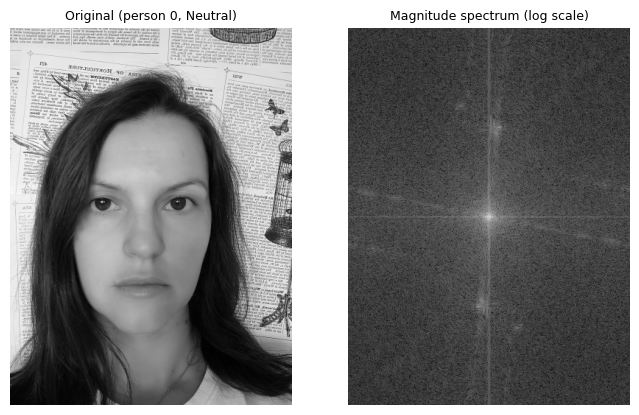

Fourier: bildestørrelse (512, 383), antall koeffisienter 196096


In [2]:
bilde = til_01(les_graa(0, "Neutral"))
F = np.fft.fftshift(np.fft.fft2(bilde))
spektrum = np.log1p(np.abs(F))

fig, akser = plt.subplots(1, 2, figsize=(8, 5))
vis(akser[0], bilde, "Original (person 0, Neutral)", vmin=0, vmax=1)
vis(akser[1], spektrum, "Magnitude spectrum (log scale)")
lagre_figur("fig_fourier_1_spektrum")

logg(f"Fourier: bildestørrelse {bilde.shape}, antall koeffisienter {F.size}")

## Masker og filtrering

`D` er avstanden fra sentrum av spekteret til hver koeffisient. Lav `D` betyr lav frekvens.

- **Ideell low-pass:** behold alt innenfor en sirkel med gitt radius, fjern resten.
- **Gaussisk low-pass:** demp gradvis med økende avstand, uten skarp grense.
- **High-pass:** det motsatte, altså `1 - low-pass`.

`filtrer` ganger spekteret med masken og transformerer tilbake til et bilde.

In [3]:
rader, kolonner = bilde.shape
y, x = np.indices(bilde.shape)
D = np.hypot(y - rader // 2, x - kolonner // 2)

def ideell_lavpass(radius):
    return (D <= radius).astype(float)

def gauss_lavpass(radius):
    return np.exp(-D ** 2 / (2 * radius ** 2))

def filtrer(bilde, maske):
    F = np.fft.fftshift(np.fft.fft2(bilde))
    return np.fft.ifft2(np.fft.ifftshift(F * maske)).real

## 1.2 Low-pass mot støy

Originalbildet har lite støy. For å kunne vise støyfjerning legger vi på gaussisk støy med standardavvik 0,08.
Deretter filtrerer vi med fire radier og begge masketyper. Tallet i tittelen er MSE mot det **rene** bildet,
så lavere tall betyr at filteret har kommet nærmere originalen.

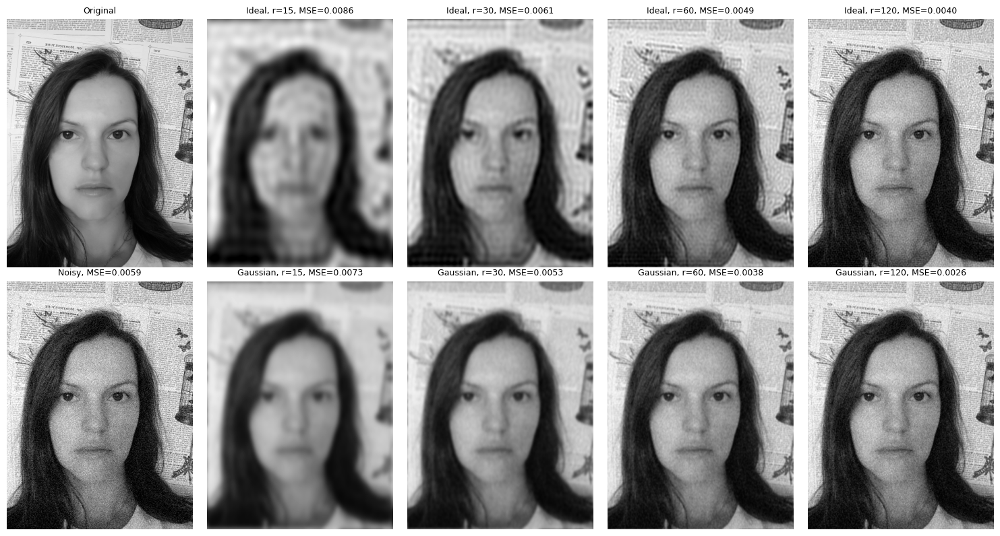

In [4]:
rng = np.random.default_rng(FRO)
stoybilde = np.clip(bilde + rng.normal(0, 0.08, bilde.shape), 0, 1)
RADIER_LP = [15, 30, 60, 120]

fig, akser = plt.subplots(2, 5, figsize=(15, 8))
vis(akser[0, 0], bilde, "Original", vmin=0, vmax=1)
vis(akser[1, 0], stoybilde, f"Noisy, MSE={mse(stoybilde, bilde):.4f}", vmin=0, vmax=1)
for i, radius in enumerate(RADIER_LP):
    ideell = filtrer(stoybilde, ideell_lavpass(radius))
    gauss = filtrer(stoybilde, gauss_lavpass(radius))
    vis(akser[0, i + 1], ideell, f"Ideal, r={radius}, MSE={mse(ideell, bilde):.4f}", vmin=0, vmax=1)
    vis(akser[1, i + 1], gauss, f"Gaussian, r={radius}, MSE={mse(gauss, bilde):.4f}", vmin=0, vmax=1)
plt.tight_layout()
lagre_figur("fig_fourier_2_lavpass")

Hvilken radius er best? Vi regner MSE mot det rene bildet for mange radier.
For liten radius fjerner detaljer, for stor radius slipper støyen gjennom. Minimum ligger et sted imellom.

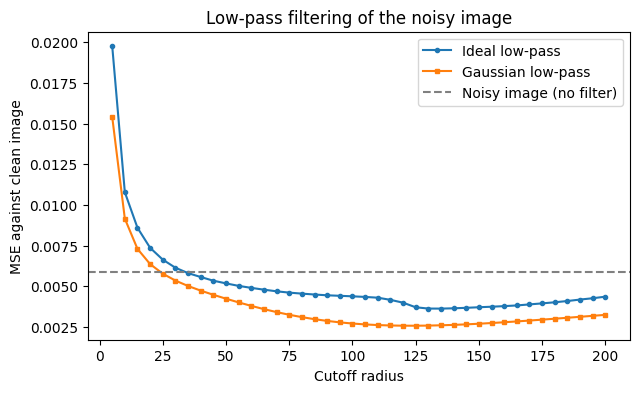

Low-pass: MSE støybilde uten filter = 0.00588
Low-pass: beste radius ideell = 135, MSE = 0.00362
Low-pass: beste radius gaussisk = 125, MSE = 0.00257


In [5]:
radier = np.arange(5, 201, 5)
mse_ideell = [mse(filtrer(stoybilde, ideell_lavpass(r)), bilde) for r in radier]
mse_gauss = [mse(filtrer(stoybilde, gauss_lavpass(r)), bilde) for r in radier]

plt.figure(figsize=(7, 4))
plt.plot(radier, mse_ideell, marker="o", markersize=3, label="Ideal low-pass")
plt.plot(radier, mse_gauss, marker="s", markersize=3, label="Gaussian low-pass")
plt.axhline(mse(stoybilde, bilde), color="gray", linestyle="--", label="Noisy image (no filter)")
plt.xlabel("Cutoff radius")
plt.ylabel("MSE against clean image")
plt.title("Low-pass filtering of the noisy image")
plt.legend()
lagre_figur("fig_fourier_3_lavpass_mse")

logg(f"Low-pass: MSE støybilde uten filter = {mse(stoybilde, bilde):.5f}")
logg(f"Low-pass: beste radius ideell = {radier[np.argmin(mse_ideell)]}, MSE = {min(mse_ideell):.5f}")
logg(f"Low-pass: beste radius gaussisk = {radier[np.argmin(mse_gauss)]}, MSE = {min(mse_gauss):.5f}")

**Ringing.** Den ideelle masken kutter brått. Det gir bølger rundt skarpe kanter (ringing).
Vi forstørrer et utsnitt rundt øynene på det rene bildet for å se forskjellen på de to masketypene.

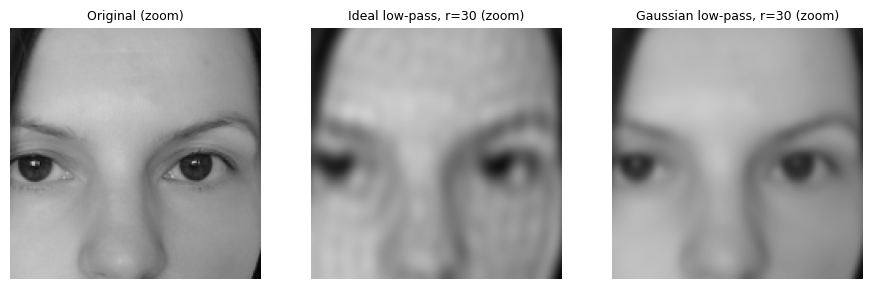

In [6]:
utsnitt = (slice(150, 310), slice(110, 270))

fig, akser = plt.subplots(1, 3, figsize=(11, 4))
vis(akser[0], bilde[utsnitt], "Original (zoom)", vmin=0, vmax=1)
vis(akser[1], filtrer(bilde, ideell_lavpass(30))[utsnitt], "Ideal low-pass, r=30 (zoom)", vmin=0, vmax=1)
vis(akser[2], filtrer(bilde, gauss_lavpass(30))[utsnitt], "Gaussian low-pass, r=30 (zoom)", vmin=0, vmax=1)
lagre_figur("fig_fourier_4_ringing")

## 1.3 High-pass for kanter

High-pass fjerner de lave frekvensene (jevne flater og lysnivå) og beholder raske endringer (kanter).
Resultatet har verdier rundt null, både positive og negative, så vi lar `imshow` skalere gråtonene selv.

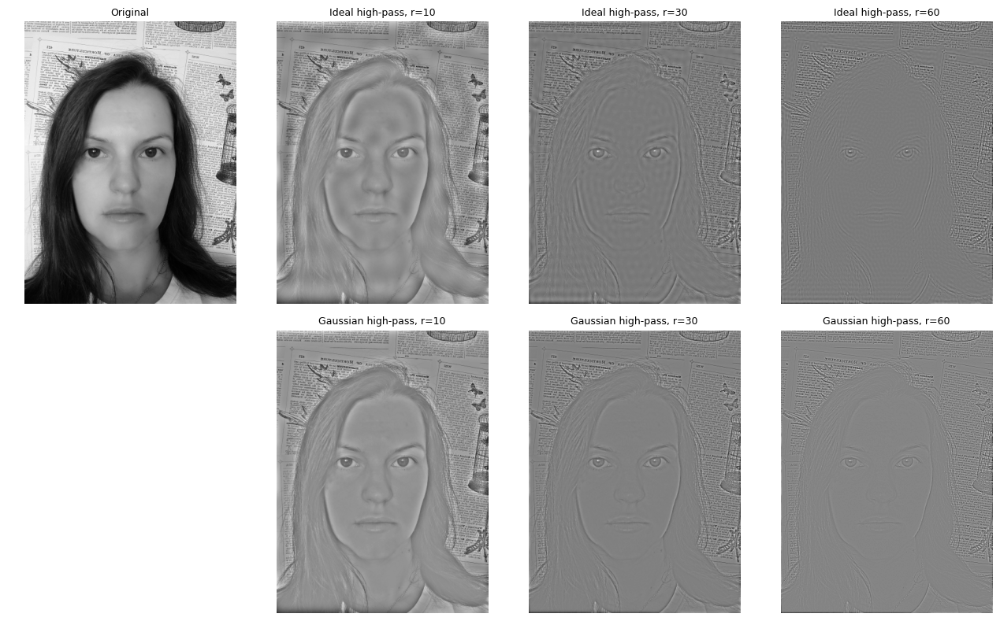

In [7]:
RADIER_HP = [10, 30, 60]

fig, akser = plt.subplots(2, 4, figsize=(13, 8))
vis(akser[0, 0], bilde, "Original", vmin=0, vmax=1)
akser[1, 0].axis("off")
for i, radius in enumerate(RADIER_HP):
    vis(akser[0, i + 1], filtrer(bilde, 1 - ideell_lavpass(radius)), f"Ideal high-pass, r={radius}")
    vis(akser[1, i + 1], filtrer(bilde, 1 - gauss_lavpass(radius)), f"Gaussian high-pass, r={radius}")
plt.tight_layout()
lagre_figur("fig_fourier_5_hoypass")

**Kantforsterkning.** Oppgaven ber om å fremheve kantene. Legger vi high-pass-bildet oppå originalen,
får vi det samme bildet med skarpere kanter.

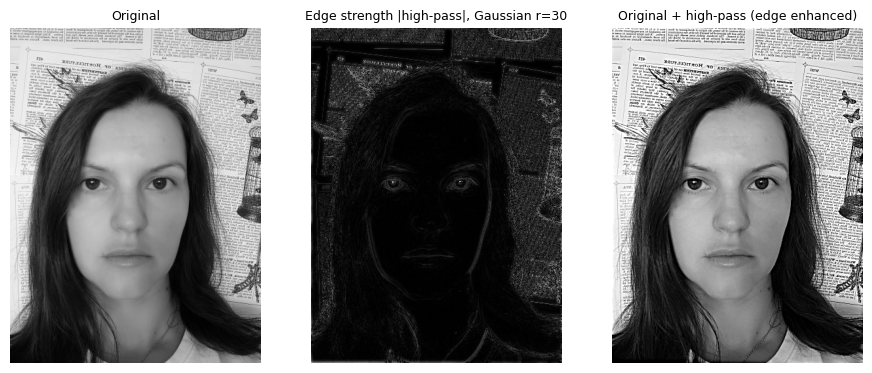

In [8]:
kanter = filtrer(bilde, 1 - gauss_lavpass(30))
forsterket = np.clip(bilde + kanter, 0, 1)

fig, akser = plt.subplots(1, 3, figsize=(11, 5))
vis(akser[0], bilde, "Original", vmin=0, vmax=1)
vis(akser[1], np.abs(kanter), "Edge strength |high-pass|, Gaussian r=30")
vis(akser[2], forsterket, "Original + high-pass (edge enhanced)", vmin=0, vmax=1)
lagre_figur("fig_fourier_6_kantforsterkning")

## 1.4 Komprimering

Vi beholder bare de p % største koeffisientene (målt i absoluttverdi) og setter resten til null.

- `np.percentile` finner grensen: en koeffisient beholdes hvis den er minst like stor som grensen.
- Kompresjonsforholdet er antall koeffisienter totalt delt på antall vi beholder.
- Kvaliteten måles med MSE og PSNR. Høyere PSNR er bedre.

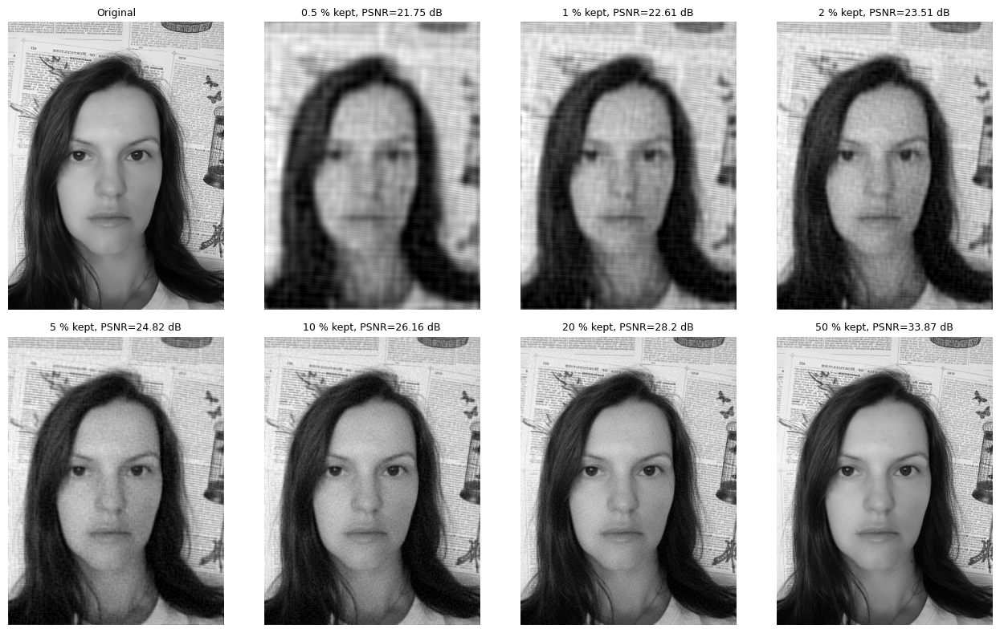

,prosent,beholdt,kompresjonsforhold,MSE,PSNR_dB
0,0.5,981,199.9,0.006690,21.75
1,1.0,1961,100.0,0.005481,22.61
2,2.0,3923,50.0,0.004456,23.51
3,5.0,9805,20.0,0.003293,24.82
4,10.0,19611,10.0,0.002419,26.16
5,20.0,39221,5.0,0.001513,28.20
6,50.0,98048,2.0,0.000410,33.87


In [9]:
PROSENTER = [0.5, 1, 2, 5, 10, 20, 50]

def komprimer(bilde, prosent):
    F = np.fft.fftshift(np.fft.fft2(bilde))
    grense = np.percentile(np.abs(F), 100 - prosent)
    beholdt = np.abs(F) >= grense
    rekonstruert = np.fft.ifft2(np.fft.ifftshift(F * beholdt)).real
    return rekonstruert, beholdt

linjer = []
fig, akser = plt.subplots(2, 4, figsize=(13, 8))
vis(akser[0, 0], bilde, "Original", vmin=0, vmax=1)
for ax, prosent in zip(akser.ravel()[1:], PROSENTER):
    rekonstruert, beholdt = komprimer(bilde, prosent)
    linjer.append({"prosent": prosent,
                   "beholdt": int(beholdt.sum()),
                   "kompresjonsforhold": round(F.size / beholdt.sum(), 1),
                   "MSE": round(mse(rekonstruert, bilde), 6),
                   "PSNR_dB": round(psnr(rekonstruert, bilde), 2)})
    vis(ax, rekonstruert, f"{prosent} % kept, PSNR={linjer[-1]['PSNR_dB']} dB", vmin=0, vmax=1)
plt.tight_layout()
lagre_figur("fig_fourier_7_komprimering")

tabell_komprimering = pd.DataFrame(linjer)
lagre_tabell(tabell_komprimering, "tab_fourier_komprimering")

Hvilke koeffisienter overlever? Hvite punkter er koeffisienter som beholdes. Sentrum er lave frekvenser.

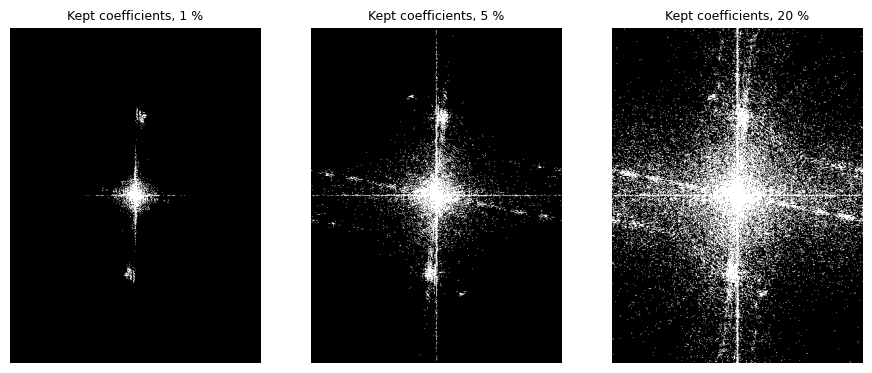

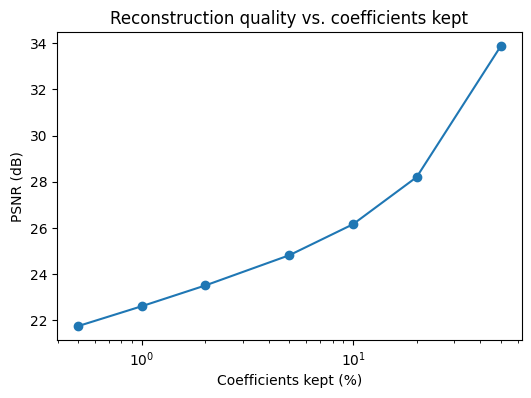

In [10]:
fig, akser = plt.subplots(1, 3, figsize=(11, 5))
for ax, prosent in zip(akser, [1, 5, 20]):
    vis(ax, komprimer(bilde, prosent)[1], f"Kept coefficients, {prosent} %")
lagre_figur("fig_fourier_8_beholdte_koeffisienter")

plt.figure(figsize=(6, 4))
plt.plot(tabell_komprimering["prosent"], tabell_komprimering["PSNR_dB"], marker="o")
plt.xscale("log")
plt.xlabel("Coefficients kept (%)")
plt.ylabel("PSNR (dB)")
plt.title("Reconstruction quality vs. coefficients kept")
lagre_figur("fig_fourier_9_psnr")

---
# Del 2: PCA

Vi bruker de 149 ansiktsutsnittene på 64×64 piksler.

## 2.1 Data

Hvert bilde brettes ut til én rad med 4096 tall. `X` får derfor 149 rader (bilder) og 4096 kolonner (piksler).

In [11]:
ansikter = np.load("ansikter_64.npy")
etiketter = pd.read_csv("ansikter_64.csv")
X = til_01(ansikter).reshape(len(ansikter), -1)
logg(f"PCA: X har form {X.shape}, verdier fra {X.min():.2f} til {X.max():.2f}")

PCA: X har form (149, 4096), verdier fra 0.00 til 1.00


## 2.2 PCA-funksjonene

Funksjonene følger stegene i oppgaven:

1. Bildene ligger som rader i `X` (gjort over).
2. Kovariansmatrisen beregnes med `np.cov` etter at gjennomsnittsbildet er trukket fra.
3. `np.linalg.eigh` gir egenverdier og egenvektorer. Den er laget for symmetriske matriser, som en kovariansmatrise er.
4. Vi sorterer fra størst til minst egenverdi.
5. De `k` første egenvektorene er hovedkomponentene.
6. Projeksjonen er sentrert data ganget med disse egenvektorene.

`pca_tilpass` tar omtrent et halvt minutt, fordi kovariansmatrisen er 4096×4096. Vi kjører den bare én gang.

In [12]:
def pca_tilpass(X):
    snitt = X.mean(axis=0)
    X_sentrert = X - snitt
    kovarians = np.cov(X_sentrert, rowvar=False)                # steg 2
    egenverdier, egenvektorer = np.linalg.eigh(kovarians)       # steg 3
    rekkefolge = np.argsort(egenverdier)[::-1]                  # steg 4
    egenverdier = np.clip(egenverdier[rekkefolge], 0, None)     # fjerner bittesmå negative avrundingsfeil
    return snitt, egenverdier, egenvektorer[:, rekkefolge]

def pca_projiser(X, snitt, W, k):
    return (X - snitt) @ W[:, :k]                               # steg 5 og 6

def pca_rekonstruer(Z, snitt, W, k):
    return Z @ W[:, :k].T + snitt

snitt, egenverdier, W = pca_tilpass(X)
logg(f"PCA: antall egenverdier over 1e-10 = {(egenverdier > 1e-10).sum()}")

PCA: antall egenverdier over 1e-10 = 147


## 2.3 Hva har PCA lært?

Hver egenvektor har 4096 tall og kan vises som et 64×64-bilde (et «egenansikt»).
Det første bildet er gjennomsnittsansiktet, deretter følger de 11 første komponentene.

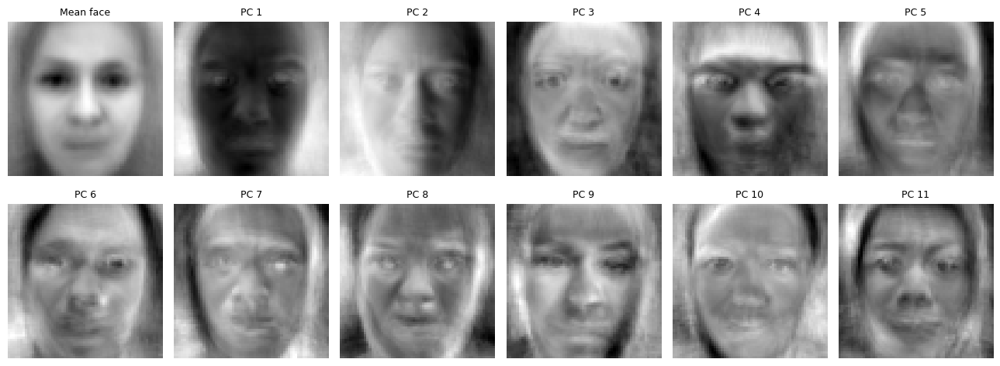

In [13]:
fig, akser = plt.subplots(2, 6, figsize=(13, 5))
vis(akser[0, 0], snitt.reshape(64, 64), "Mean face")
for i, ax in enumerate(akser.ravel()[1:]):
    vis(ax, W[:, i].reshape(64, 64), f"PC {i + 1}")
plt.tight_layout()
lagre_figur("fig_pca_1_egenansikter")

## 2.4 Rekonstruksjon for ulike k

Fire faste bilder rekonstrueres med økende antall komponenter. Høyeste k er antall bilder minus én.

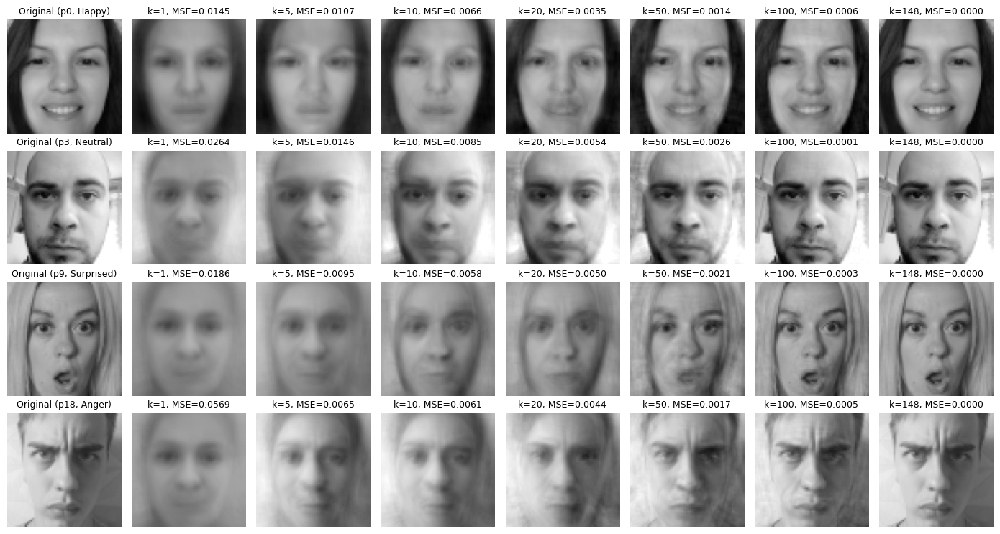

In [14]:
K_MAKS = len(X) - 1
K_VERDIER = [1, 5, 10, 20, 50, 100, K_MAKS]
FASTE = [(0, "Happy"), (3, "Neutral"), (9, "Surprised"), (18, "Anger")]

def finn_indeks(person, uttrykk):
    treff = etiketter[(etiketter["person"] == person) & (etiketter["uttrykk"] == uttrykk)]
    return treff.index[0]

fig, akser = plt.subplots(len(FASTE), len(K_VERDIER) + 1, figsize=(14, 7.5))
for rad, (person, uttrykk) in enumerate(FASTE):
    i = finn_indeks(person, uttrykk)
    vis(akser[rad, 0], X[i].reshape(64, 64), f"Original (p{person}, {uttrykk})", vmin=0, vmax=1)
    for kol, k in enumerate(K_VERDIER):
        rekonstruert = pca_rekonstruer(pca_projiser(X[i:i + 1], snitt, W, k), snitt, W, k)
        vis(akser[rad, kol + 1], rekonstruert.reshape(64, 64),
            f"k={k}, MSE={mse(rekonstruert, X[i]):.4f}", vmin=0, vmax=1)
plt.tight_layout()
lagre_figur("fig_pca_2_rekonstruksjon")

## 2.5 Forklart varians

Egenverdien til en komponent er variansen den forklarer. Vi deler på summen og legger sammen fortløpende
for å se hvor mange komponenter som trengs for 90 % og 95 % av variansen.

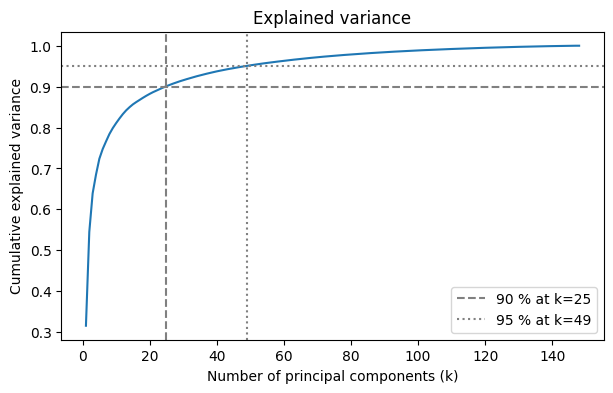

PCA: 90 % varians ved k = 25, 95 % ved k = 49
PCA: andel varians for PC1-PC5 = 0.316, 0.229, 0.094, 0.046, 0.039


In [15]:
andel = egenverdier / egenverdier.sum()
kumulativ = np.cumsum(andel)
k90 = int(np.argmax(kumulativ >= 0.90)) + 1
k95 = int(np.argmax(kumulativ >= 0.95)) + 1

plt.figure(figsize=(7, 4))
plt.plot(np.arange(1, K_MAKS + 1), kumulativ[:K_MAKS])
plt.axhline(0.90, color="gray", linestyle="--")
plt.axhline(0.95, color="gray", linestyle=":")
plt.axvline(k90, color="gray", linestyle="--", label=f"90 % at k={k90}")
plt.axvline(k95, color="gray", linestyle=":", label=f"95 % at k={k95}")
plt.xlabel("Number of principal components (k)")
plt.ylabel("Cumulative explained variance")
plt.title("Explained variance")
plt.legend()
lagre_figur("fig_pca_3_forklart_varians")

logg(f"PCA: 90 % varians ved k = {k90}, 95 % ved k = {k95}")
logg("PCA: andel varians for PC1-PC5 = " + ", ".join(f"{a:.3f}" for a in andel[:5]))

## 2.6 MSE og avveining mot komprimering

For hver k regner vi MSE over alle bildene. Lagringsbehovet med PCA er:
k tall per bilde, pluss k egenvektorer med 4096 tall hver, pluss gjennomsnittsbildet.
Kompresjonsforholdet er lagring uten PCA delt på lagring med PCA.

,k,MSE,forklart_varians,lagrede_tall,kompresjonsforhold
0,1,0.025277,0.3156,8341,73.17
1,5,0.010203,0.7237,25321,24.10
2,10,0.006984,0.8109,46546,13.11
3,20,0.004347,0.8823,88996,6.86
4,50,0.001769,0.9521,216346,2.82
5,100,0.000425,0.9885,428596,1.42
6,148,0.000000,1.0000,632356,0.97


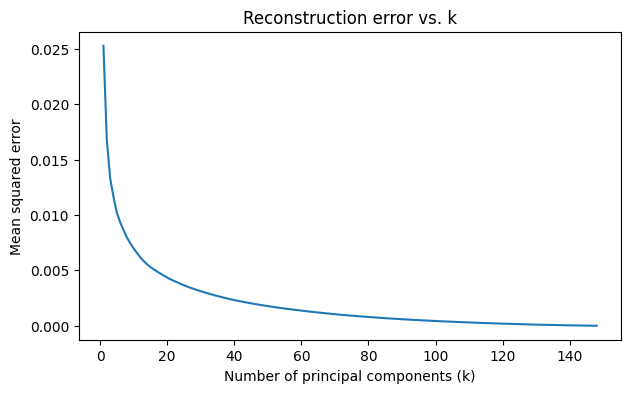

In [16]:
def mse_per_bilde(X, snitt, W, k):
    rekonstruert = pca_rekonstruer(pca_projiser(X, snitt, W, k), snitt, W, k)
    return np.mean((X - rekonstruert) ** 2, axis=1)

n, d = X.shape
linjer = []
for k in K_VERDIER:
    lagring = n * k + k * d + d
    linjer.append({"k": k,
                   "MSE": round(mse_per_bilde(X, snitt, W, k).mean(), 6),
                   "forklart_varians": round(kumulativ[k - 1], 4),
                   "lagrede_tall": lagring,
                   "kompresjonsforhold": round(n * d / lagring, 2)})
tabell_pca = pd.DataFrame(linjer)
lagre_tabell(tabell_pca, "tab_pca_mse")

alle_k = np.arange(1, K_MAKS + 1)
mse_alle_k = [mse_per_bilde(X, snitt, W, k).mean() for k in alle_k]

plt.figure(figsize=(7, 4))
plt.plot(alle_k, mse_alle_k)
plt.xlabel("Number of principal components (k)")
plt.ylabel("Mean squared error")
plt.title("Reconstruction error vs. k")
lagre_figur("fig_pca_4_mse")

## 2.7 Hvilke bilder er vanskeligst?

Datasettet har åtte uttrykk per person. Ved k = 20 ser vi på feilen gruppert per person og per uttrykk.

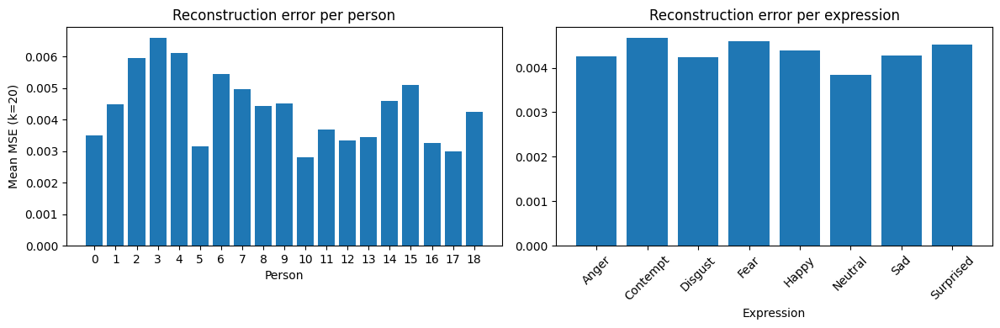

PCA: MSE per person (k=20): p0=0.0035, p1=0.0045, p2=0.0059, p3=0.0066, p4=0.0061, p5=0.0032, p6=0.0054, p7=0.0050, p8=0.0044, p9=0.0045, p10=0.0028, p11=0.0037, p12=0.0033, p13=0.0034, p14=0.0046, p15=0.0051, p16=0.0033, p17=0.0030, p18=0.0042
PCA: MSE per uttrykk (k=20): Anger=0.0043, Contempt=0.0047, Disgust=0.0042, Fear=0.0046, Happy=0.0044, Neutral=0.0038, Sad=0.0043, Surprised=0.0045
PCA: spredning mellom personer (std) = 0.00113, mellom uttrykk (std) = 0.00027


In [17]:
etiketter["mse_k20"] = mse_per_bilde(X, snitt, W, 20)
per_person = etiketter.groupby("person")["mse_k20"].mean()
per_uttrykk = etiketter.groupby("uttrykk")["mse_k20"].mean()

fig, akser = plt.subplots(1, 2, figsize=(12, 4))
akser[0].bar(per_person.index.astype(str), per_person.values)
akser[0].set_xlabel("Person")
akser[0].set_ylabel("Mean MSE (k=20)")
akser[0].set_title("Reconstruction error per person")
akser[1].bar(per_uttrykk.index, per_uttrykk.values)
akser[1].set_xlabel("Expression")
akser[1].set_title("Reconstruction error per expression")
akser[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
lagre_figur("fig_pca_5_mse_per_gruppe")

logg("PCA: MSE per person (k=20): " + ", ".join(f"p{p}={v:.4f}" for p, v in per_person.items()))
logg("PCA: MSE per uttrykk (k=20): " + ", ".join(f"{u}={v:.4f}" for u, v in per_uttrykk.items()))
logg(f"PCA: spredning mellom personer (std) = {per_person.std():.5f}, mellom uttrykk (std) = {per_uttrykk.std():.5f}")

## 2.8 Tillegg: et ansikt PCA ikke har sett

Over rekonstruerer vi de samme bildene som PCA ble tilpasset på. Da må feilen gå mot null når k nærmer seg antall bilder.
Her holder vi person 18 utenfor, tilpasser PCA på de andre og rekonstruerer person 18.
Forskjellen mellom kurvene viser hvor mye av resultatet som skyldes at bildene er kjente.

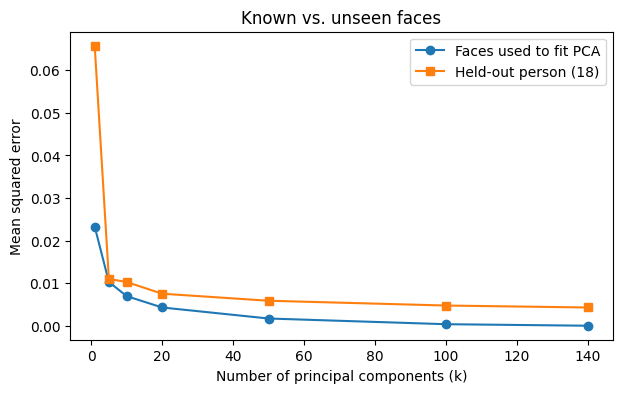

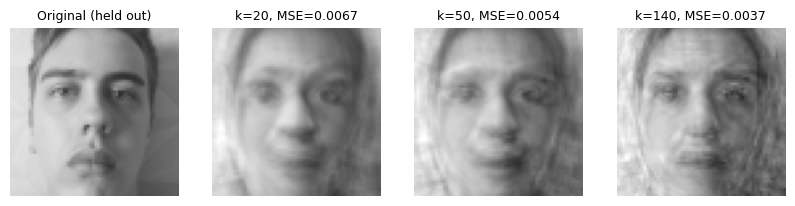

PCA ukjent person: k = 1, 5, 10, 20, 50, 100, 140
PCA ukjent person: MSE kjente = 0.02328, 0.01028, 0.00695, 0.00428, 0.00169, 0.00036, 0.00000
PCA ukjent person: MSE person 18 = 0.06576, 0.01099, 0.01027, 0.00752, 0.00587, 0.00474, 0.00428


In [18]:
ute = (etiketter["person"] == 18).values
snitt_u, egenverdier_u, W_u = pca_tilpass(X[~ute])
k_maks_u = (~ute).sum() - 1
k_liste = [k for k in K_VERDIER if k <= k_maks_u] + [k_maks_u]

mse_kjent = [mse_per_bilde(X[~ute], snitt_u, W_u, k).mean() for k in k_liste]
mse_ukjent = [mse_per_bilde(X[ute], snitt_u, W_u, k).mean() for k in k_liste]

plt.figure(figsize=(7, 4))
plt.plot(k_liste, mse_kjent, marker="o", label="Faces used to fit PCA")
plt.plot(k_liste, mse_ukjent, marker="s", label="Held-out person (18)")
plt.xlabel("Number of principal components (k)")
plt.ylabel("Mean squared error")
plt.title("Known vs. unseen faces")
plt.legend()
lagre_figur("fig_pca_6_ukjent_person")

i = np.where(ute)[0][5]     # Neutral for person 18
fig, akser = plt.subplots(1, 4, figsize=(10, 3))
vis(akser[0], X[i].reshape(64, 64), "Original (held out)", vmin=0, vmax=1)
for ax, k in zip(akser[1:], [20, 50, k_maks_u]):
    rekonstruert = pca_rekonstruer(pca_projiser(X[i:i + 1], snitt_u, W_u, k), snitt_u, W_u, k)
    vis(ax, rekonstruert.reshape(64, 64), f"k={k}, MSE={mse(rekonstruert, X[i]):.4f}", vmin=0, vmax=1)
lagre_figur("fig_pca_7_ukjent_rekonstruksjon")

logg("PCA ukjent person: k = " + ", ".join(str(k) for k in k_liste))
logg("PCA ukjent person: MSE kjente = " + ", ".join(f"{v:.5f}" for v in mse_kjent))
logg("PCA ukjent person: MSE person 18 = " + ", ".join(f"{v:.5f}" for v in mse_ukjent))

---
# Del 3: HOG

Tre bilder med økende kompleksitet: person 18 (jevn bakgrunn), person 4 (rutete skjorte) og person 5 (mye bakgrunn).

## 3.1 Gradientbilde og HOG

- **Gradientbildet** lages med Sobel-filter i x- og y-retning. Styrken er lengden av gradientvektoren.
- **HOG** deler bildet i celler, lager et histogram over gradientretninger i hver celle, og normaliserer histogrammene i blokker.
- Standardverdiene er de samme som i forelesningen: 9 retninger, celler på 8×8 piksler og blokker på 2×2 celler.

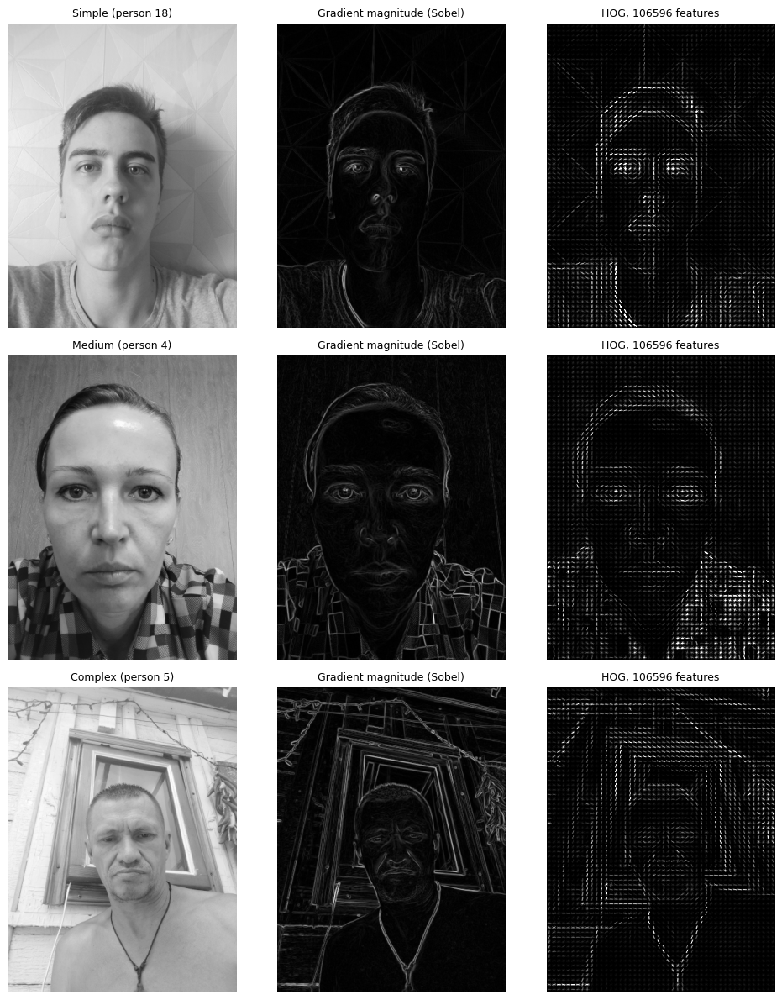

In [19]:
HOG_BILDER = [("Simple (person 18)", 18), ("Medium (person 4)", 4), ("Complex (person 5)", 5)]

def gradient(bilde):
    gx = cv2.Sobel(bilde, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(bilde, cv2.CV_64F, 0, 1, ksize=3)
    return np.hypot(gx, gy), gx, gy

def hog_trekk(bilde, retninger=9, celle=8, blokk=2):
    return hog(bilde, orientations=retninger, pixels_per_cell=(celle, celle),
               cells_per_block=(blokk, blokk), block_norm="L2-Hys", visualize=True)

def vis_hog(ax, hog_bilde, tittel):
    vis(ax, hog_bilde, tittel, vmax=np.percentile(hog_bilde, 99.5))

fig, akser = plt.subplots(3, 3, figsize=(10, 12))
for rad, (navn, person) in enumerate(HOG_BILDER):
    b = til_01(les_graa(person, "Neutral"))
    styrke, gx, gy = gradient(b)
    trekk, hog_bilde = hog_trekk(b)
    vis(akser[rad, 0], b, navn, vmin=0, vmax=1)
    vis(akser[rad, 1], styrke, "Gradient magnitude (Sobel)")
    vis_hog(akser[rad, 2], hog_bilde, f"HOG, {len(trekk)} features")
plt.tight_layout()
lagre_figur("fig_hog_1_tre_bilder")

## 3.2 Sammenligning mellom bildene

To enkle mål:

- **Gjennomsnittlig gradientstyrke** sier hvor mye kantinformasjon bildet har.
- **Samlet retningshistogram** viser hvilke gradientretninger som dominerer i hele bildet.
  0° er en vannrett gradient (altså en loddrett kant), 90° er en loddrett gradient (vannrett kant).

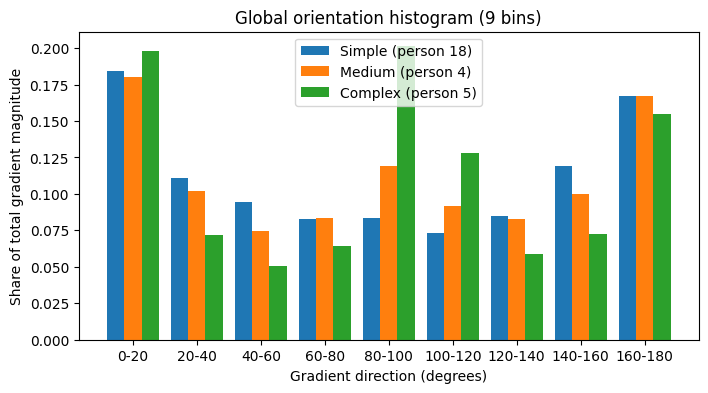

,bilde,gradientstyrke_snitt,andel_sterke_piksler,storste_retning
0,Simple (person 18),0.0929,0.1145,0-20 deg
1,Medium (person 4),0.1546,0.2015,0-20 deg
2,Complex (person 5),0.1847,0.2648,80-100 deg


In [20]:
kanter_bins = np.linspace(0, 180, 10)
linjer = []
plt.figure(figsize=(8, 4))
for i, (navn, person) in enumerate(HOG_BILDER):
    b = til_01(les_graa(person, "Neutral"))
    styrke, gx, gy = gradient(b)
    retning = np.rad2deg(np.arctan2(gy, gx)) % 180
    histogram, _ = np.histogram(retning, bins=kanter_bins, weights=styrke)
    histogram = histogram / histogram.sum()
    plt.bar(np.arange(9) + (i - 1) * 0.27, histogram, width=0.27, label=navn)
    linjer.append({"bilde": navn, "gradientstyrke_snitt": round(styrke.mean(), 4),
                   "andel_sterke_piksler": round((styrke > 0.2).mean(), 4),
                   "storste_retning": f"{int(kanter_bins[histogram.argmax()])}-{int(kanter_bins[histogram.argmax() + 1])} deg"})
plt.xticks(np.arange(9), [f"{int(a)}-{int(b)}" for a, b in zip(kanter_bins[:-1], kanter_bins[1:])])
plt.xlabel("Gradient direction (degrees)")
plt.ylabel("Share of total gradient magnitude")
plt.title("Global orientation histogram (9 bins)")
plt.legend()
lagre_figur("fig_hog_2_retningshistogram")
lagre_tabell(pd.DataFrame(linjer), "tab_hog_sammenligning")

## 3.3 Effekt av parametere

Vi endrer én parameter om gangen på det enkle bildet (person 18):

- **Cellestørrelse:** hvor stort område hvert histogram dekker.
- **Antall retninger (bins):** hvor fint retningene deles inn.
- **Blokkstørrelse:** hvor mange celler som normaliseres sammen. Den endrer ikke HOG-bildet, bare lengden og verdiene i deskriptoren.

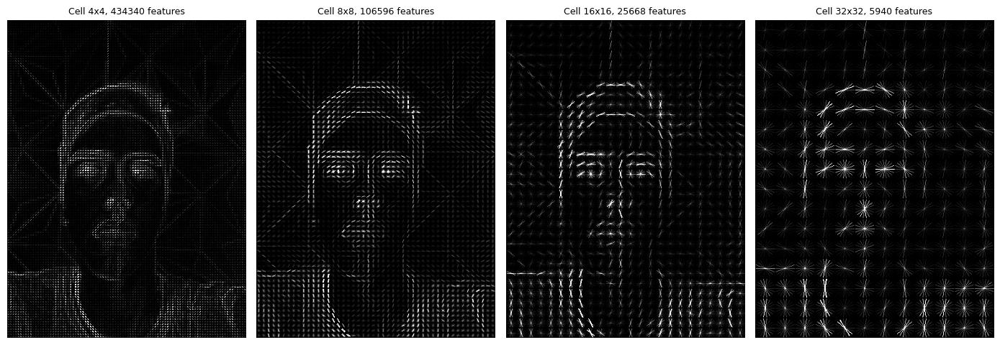

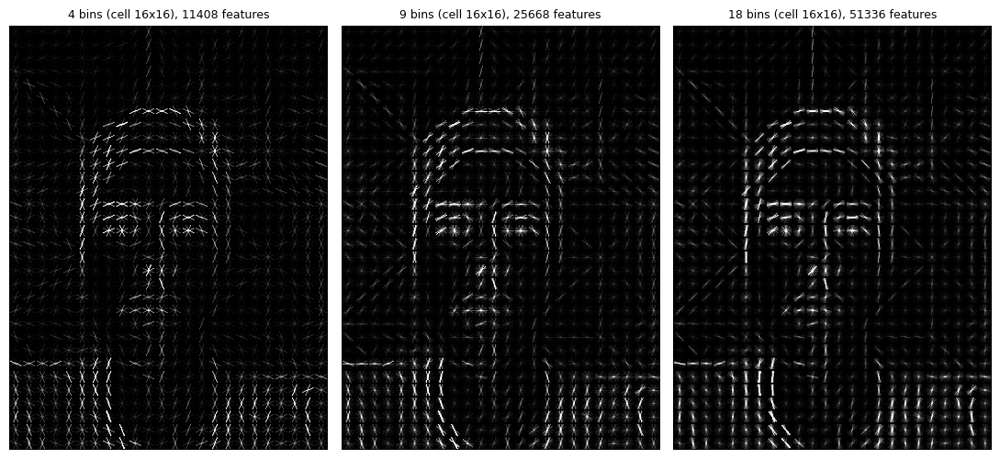

,parameter,verdi,lengde
0,cellestorrelse,4,434340
1,cellestorrelse,8,106596
2,cellestorrelse,16,25668
3,cellestorrelse,32,5940
4,blokkstorrelse,1,27648
5,blokkstorrelse,2,106596
6,blokkstorrelse,3,231012
7,bins,4,47376
8,bins,9,106596
9,bins,18,213192


In [21]:
b = til_01(les_graa(18, "Neutral"))

fig, akser = plt.subplots(1, 4, figsize=(14, 5))
for ax, celle in zip(akser, [4, 8, 16, 32]):
    trekk, hog_bilde = hog_trekk(b, celle=celle)
    vis_hog(ax, hog_bilde, f"Cell {celle}x{celle}, {len(trekk)} features")
plt.tight_layout()
lagre_figur("fig_hog_3_cellestorrelse")

fig, akser = plt.subplots(1, 3, figsize=(11, 5))
for ax, retninger in zip(akser, [4, 9, 18]):
    trekk, hog_bilde = hog_trekk(b, retninger=retninger, celle=16)
    vis_hog(ax, hog_bilde, f"{retninger} bins (cell 16x16), {len(trekk)} features")
plt.tight_layout()
lagre_figur("fig_hog_4_bins")

linjer = []
for celle in [4, 8, 16, 32]:
    linjer.append({"parameter": "cellestorrelse", "verdi": celle, "lengde": len(hog_trekk(b, celle=celle)[0])})
for blokk in [1, 2, 3]:
    linjer.append({"parameter": "blokkstorrelse", "verdi": blokk, "lengde": len(hog_trekk(b, blokk=blokk)[0])})
for retninger in [4, 9, 18]:
    linjer.append({"parameter": "bins", "verdi": retninger, "lengde": len(hog_trekk(b, retninger=retninger)[0])})
lagre_tabell(pd.DataFrame(linjer), "tab_hog_parametere")

---
# Del 4: LBP

## 4.1 LBP-funksjonen

For hver piksel ser vi på de 8 naboene. En nabo som er lik eller lysere enn senteret gir bit 1, ellers 0.
Naboene leses med klokka fra øverst til venstre, og bitene vektes med 1, 2, 4, ..., 128. Summen er LBP-koden (0–255).

Vi bruker forskyvning av hele bildet i stedet for løkker over hver piksel. `nabo` er bildet flyttet ett steg i én retning,
slik at alle piksler sammenlignes med sin nabo i den retningen på én gang. Kantpikslene har ikke 8 naboer og utelates.

In [22]:
NABOER = [(0, 0), (0, 1), (0, 2), (1, 2), (2, 2), (2, 1), (2, 0), (1, 0)]   # (rad, kolonne) i 3x3-vinduet

def lbp(bilde):
    b = bilde.astype(np.int16)
    senter = b[1:-1, 1:-1]
    hoyde, bredde = senter.shape
    koder = np.zeros(senter.shape, dtype=np.uint8)
    for bit, (r, k) in enumerate(NABOER):
        nabo = b[r:r + hoyde, k:k + bredde]
        koder += (nabo >= senter).astype(np.uint8) * (2 ** bit)
    return koder

def lbp_histogram(lbp_bilde):
    antall = np.bincount(lbp_bilde.ravel(), minlength=256)
    return antall / antall.sum()

**Regneeksempel.** Senteret er 6. Naboer som er 6 eller høyere gir 1.

In [23]:
eksempel = np.array([[5, 9, 1],
                     [4, 6, 7],
                     [2, 3, 8]], dtype=np.uint8)
biter = [int(eksempel[r, k] >= eksempel[1, 1]) for r, k in NABOER]
logg(f"LBP-eksempel: naboer med klokka = {[int(eksempel[r, k]) for r, k in NABOER]}")
logg(f"LBP-eksempel: biter = {biter}, kode = {sum(bit * 2 ** i for i, bit in enumerate(biter))}, funksjonen gir {lbp(eksempel)[0, 0]}")

LBP-eksempel: naboer med klokka = [5, 9, 1, 7, 8, 3, 2, 4]
LBP-eksempel: biter = [0, 1, 0, 1, 1, 0, 0, 0], kode = 26, funksjonen gir 26


## 4.2 Bildene

Bilde A er et helt ansikt. B, C og D er utsnitt på 96×96 piksler fra tre andre bilder: hår, hud og stoff.
Figuren viser hvor utsnittene er hentet fra. **Sjekk at rutene treffer riktig, og juster `rad` og `kol` hvis ikke.**

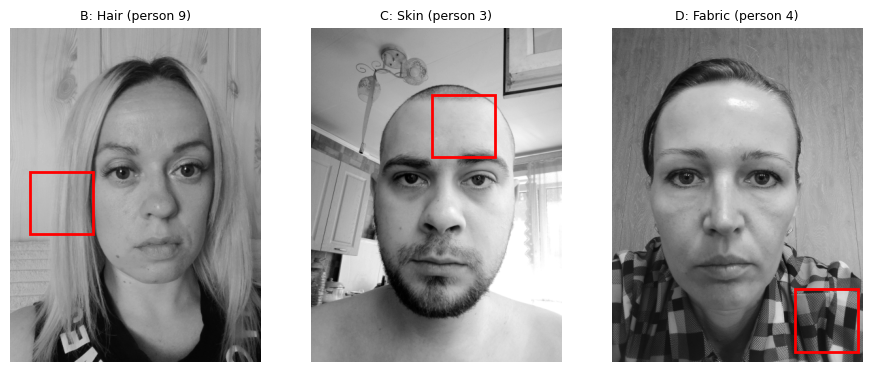

In [24]:
STR = 96
UTSNITT = {
    "B: Hair (person 9)":   {"person": 9, "rad": 220, "kol": 30},
    "C: Skin (person 3)":   {"person": 3, "rad": 102, "kol": 185},
    "D: Fabric (person 4)": {"person": 4, "rad": 400, "kol": 280},
}

lbp_bilder = {"A: Face (person 18)": les_graa(18, "Neutral")}
fig, akser = plt.subplots(1, 3, figsize=(11, 5))
for ax, (navn, u) in zip(akser, UTSNITT.items()):
    helt = les_graa(u["person"], "Neutral")
    lbp_bilder[navn] = helt[u["rad"]:u["rad"] + STR, u["kol"]:u["kol"] + STR]
    vis(ax, helt, navn, vmin=0, vmax=255)
    ax.add_patch(plt.Rectangle((u["kol"], u["rad"]), STR, STR, fill=False, edgecolor="red", linewidth=2))
lagre_figur("fig_lbp_1_utsnitt")

## 4.3 LBP-bilde og histogram

For hvert bilde vises originalen, LBP-bildet og histogrammet. Histogrammet er normalisert,
slik at søylene viser andel av pikslene og bilder av ulik størrelse kan sammenlignes.

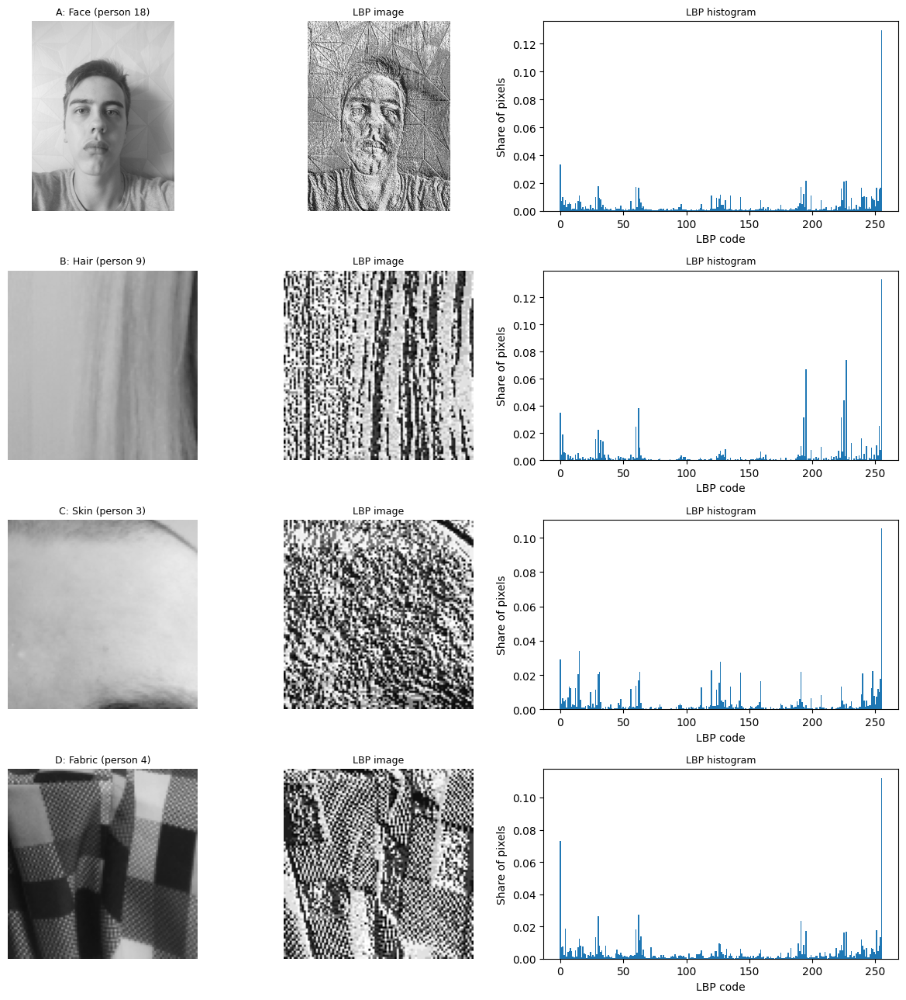

In [25]:
histogrammer = {}
fig, akser = plt.subplots(4, 3, figsize=(12, 13), gridspec_kw={"width_ratios": [1, 1, 1.6]})
for rad, (navn, b) in enumerate(lbp_bilder.items()):
    koder = lbp(b)
    histogrammer[navn] = lbp_histogram(koder)
    vis(akser[rad, 0], b, navn, vmin=0, vmax=255)
    vis(akser[rad, 1], koder, "LBP image", vmin=0, vmax=255)
    akser[rad, 2].bar(np.arange(256), histogrammer[navn], width=1.0)
    akser[rad, 2].set_title("LBP histogram", fontsize=9)
    akser[rad, 2].set_xlabel("LBP code")
    akser[rad, 2].set_ylabel("Share of pixels")
plt.tight_layout()
lagre_figur("fig_lbp_2_bilder_og_histogram")

## 4.4 Sammenligning av histogrammene

- Tabellen viser andelen i kode 255 (alle naboer minst like lyse som senteret, typisk flate områder),
  andelen i kode 0 (senteret lysere enn alle naboer) og de fem vanligste kodene.
- Chi-kvadrat-avstanden måler hvor ulike to histogrammer er. 0 betyr identiske.

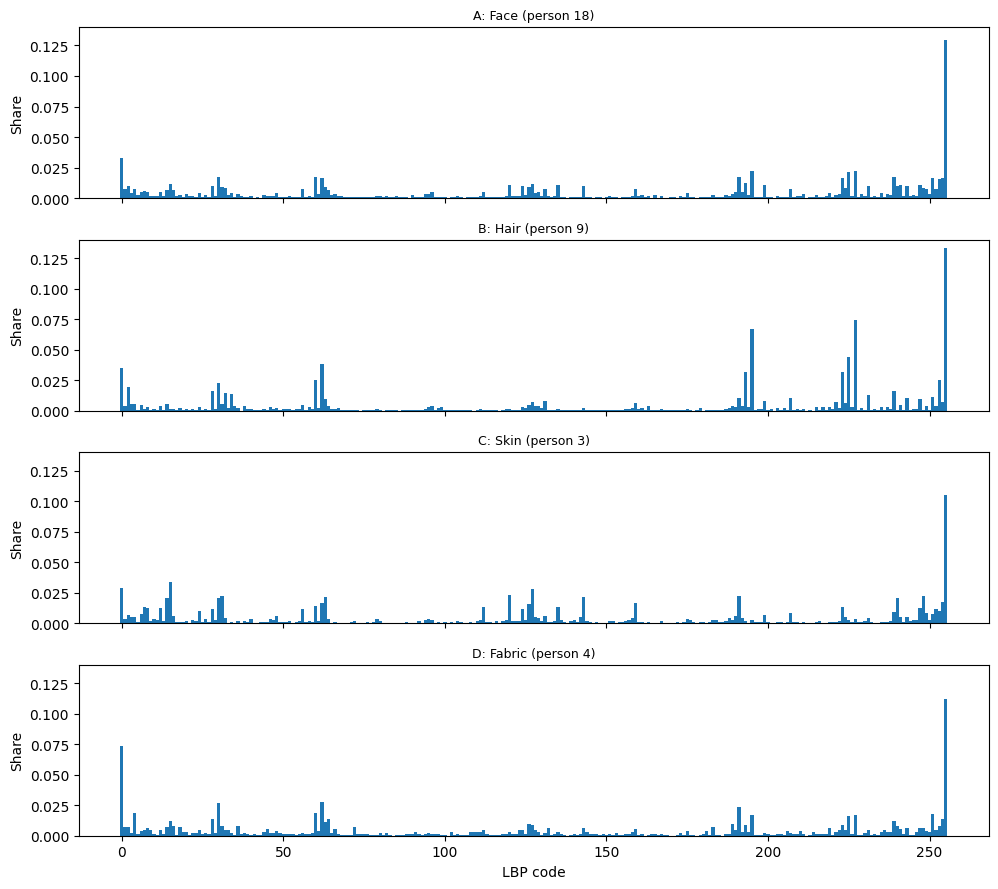

,bilde,andel_kode_255,andel_kode_0,fem_vanligste_koder,andel_i_fem_vanligste
0,A: Face (person 18),0.1296,0.0331,"255, 0, 227, 195, 225",0.2276
1,B: Hair (person 9),0.1332,0.0351,"255, 227, 195, 225, 62",0.3569
2,C: Skin (person 3),0.1053,0.0291,"255, 15, 0, 127, 120",0.2191
3,D: Fabric (person 4),0.1122,0.0731,"255, 0, 62, 30, 191",0.2628


,bilde,A,B,C,D
0,A,0.0000,0.1261,0.1107,0.0773
1,B,0.1261,0.0000,0.2885,0.1928
2,C,0.1107,0.2885,0.0000,0.1662
3,D,0.0773,0.1928,0.1662,0.0000


In [26]:
fig, akser = plt.subplots(4, 1, figsize=(10, 9), sharex=True, sharey=True)
for ax, (navn, h) in zip(akser, histogrammer.items()):
    ax.bar(np.arange(256), h, width=1.0)
    ax.set_title(navn, fontsize=9)
    ax.set_ylabel("Share")
akser[-1].set_xlabel("LBP code")
plt.tight_layout()
lagre_figur("fig_lbp_3_histogrammer_samlet")

linjer = []
for navn, h in histogrammer.items():
    topp = np.argsort(h)[::-1][:5]
    linjer.append({"bilde": navn, "andel_kode_255": round(h[255], 4), "andel_kode_0": round(h[0], 4),
                   "fem_vanligste_koder": ", ".join(str(int(k)) for k in topp),
                   "andel_i_fem_vanligste": round(h[topp].sum(), 4)})
lagre_tabell(pd.DataFrame(linjer), "tab_lbp_histogram")

def chi_kvadrat(h1, h2):
    return 0.5 * np.sum((h1 - h2) ** 2 / (h1 + h2 + 1e-12))

navn_liste = list(histogrammer)
avstand = pd.DataFrame([[round(chi_kvadrat(histogrammer[a], histogrammer[b]), 4) for b in navn_liste] for a in navn_liste],
                       columns=[n[:1] for n in navn_liste])
avstand.insert(0, "bilde", [n[:1] for n in navn_liste])
lagre_tabell(avstand, "tab_lbp_avstand")

---
# Del 5: Blob detection

Vi bruker `cv2.SimpleBlobDetector`, metoden fra forelesningen, på åtte bilder: person 3, 9, 13 og 18 med Neutral og Surprised.

## 5.1 Detektoren

Detektoren terskler bildet på mange nivåer (fra `min_terskel` til `maks_terskel` i steg), grupperer sammenhengende piksler
på hvert nivå, og slår sammen grupper som ligger på samme sted. Det som går igjen på flere nivåer, blir en blob.

- `farge=0` leter etter mørke blobs, `farge=255` etter lyse.
- `min_areal` og `maks_areal` fjerner for små og for store områder.
- `min_sirkularitet` kan kreve at blobben er rund (1 er en perfekt sirkel).

In [27]:
BLOB_BILDER = [(person, uttrykk) for person in [3, 9, 13, 18] for uttrykk in ["Neutral", "Surprised"]]

def finn_blobs(bilde, min_terskel=10, maks_terskel=200, steg=10, farge=0,
               min_areal=30, maks_areal=5000, min_sirkularitet=None):
    p = cv2.SimpleBlobDetector_Params()
    p.minThreshold, p.maxThreshold, p.thresholdStep = min_terskel, maks_terskel, steg
    p.filterByColor, p.blobColor = True, farge
    p.filterByArea, p.minArea, p.maxArea = True, min_areal, maks_areal
    p.filterByConvexity = False
    p.filterByInertia = False
    p.filterByCircularity = min_sirkularitet is not None
    if min_sirkularitet is not None:
        p.minCircularity = min_sirkularitet
    punkter = cv2.SimpleBlobDetector_create(p).detect(bilde)
    return pd.DataFrame([{"x": round(k.pt[0], 1), "y": round(k.pt[1], 1), "diameter": round(k.size, 1)}
                         for k in punkter], columns=["x", "y", "diameter"])

def tegn_blobs(bilde, blobs):
    farget = cv2.cvtColor(bilde, cv2.COLOR_GRAY2RGB)
    for _, blob in blobs.iterrows():
        cv2.circle(farget, (int(blob["x"]), int(blob["y"])), max(int(blob["diameter"] / 2), 2), (255, 0, 0), 2)
    return farget

## 5.2 Blobs på de åtte bildene, med statistikk

Hver blob tegnes som en rød sirkel. Tabellen viser antall, størrelse (diameter) og gjennomsnittlig posisjon per bilde.

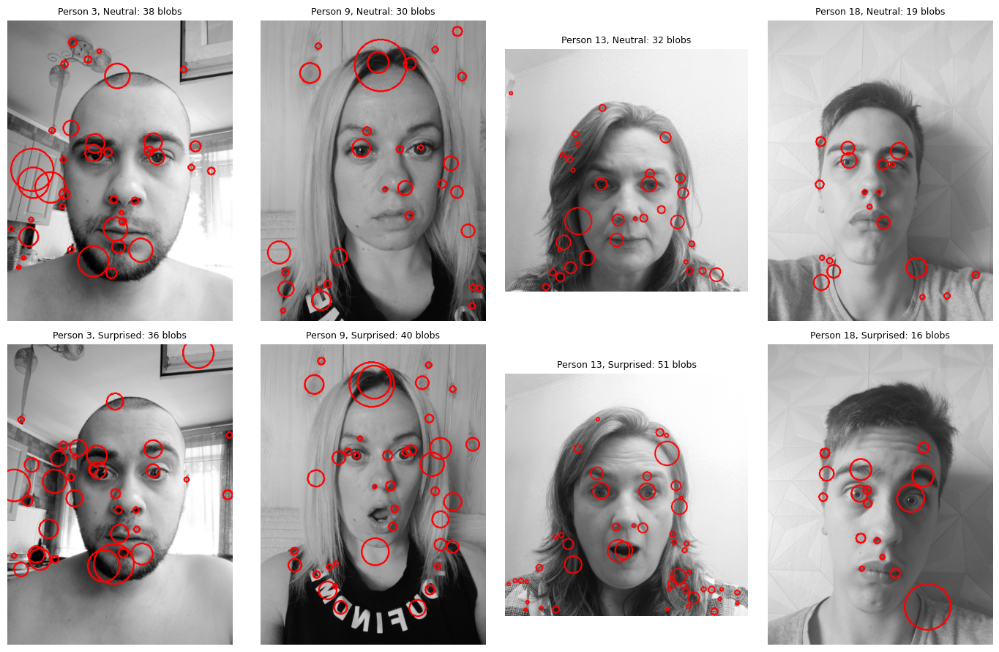

,person,uttrykk,antall,diameter_snitt,diameter_min,diameter_maks,x_snitt,y_snitt
0,3,Neutral,38,22.5,7.2,73.1,152.0,264.0
1,3,Surprised,36,26.0,8.3,69.6,151.0,254.0
2,9,Neutral,30,21.2,8.4,88.8,214.0,280.0
3,9,Surprised,40,21.9,7.1,77.6,212.0,248.0
4,13,Neutral,32,19.9,7.5,56.5,237.0,342.0
5,13,Surprised,51,16.3,6.6,51.0,275.0,372.0
6,18,Neutral,19,17.1,7.4,34.6,178.0,336.0
7,18,Surprised,16,24.9,9.5,79.3,182.0,285.0


In [28]:
linjer = []
blob_antall = {}
fig, akser = plt.subplots(2, 4, figsize=(14, 9))
for kol, (person, uttrykk) in enumerate(BLOB_BILDER):
    b = les_graa(person, uttrykk)
    blobs = finn_blobs(b)
    blob_antall[(person, uttrykk)] = len(blobs)
    ax = akser[kol % 2, kol // 2]
    ax.imshow(tegn_blobs(b, blobs))
    ax.set_title(f"Person {person}, {uttrykk}: {len(blobs)} blobs", fontsize=9)
    ax.axis("off")
    linjer.append({"person": person, "uttrykk": uttrykk, "antall": len(blobs),
                   "diameter_snitt": round(blobs["diameter"].mean(), 1) if len(blobs) else 0,
                   "diameter_min": blobs["diameter"].min() if len(blobs) else 0,
                   "diameter_maks": blobs["diameter"].max() if len(blobs) else 0,
                   "x_snitt": round(blobs["x"].mean(), 0) if len(blobs) else 0,
                   "y_snitt": round(blobs["y"].mean(), 0) if len(blobs) else 0})
plt.tight_layout()
lagre_figur("fig_blob_1_atte_bilder")
lagre_tabell(pd.DataFrame(linjer), "tab_blob_per_bilde")

Posisjon og størrelse for hver enkelt blob i to av bildene:

In [29]:
EKSPERIMENT_BILDER = [(3, "Neutral"), (9, "Surprised")]
for person, uttrykk in EKSPERIMENT_BILDER:
    blobs = finn_blobs(les_graa(person, uttrykk)).sort_values("y").reset_index(drop=True)
    lagre_tabell(blobs, f"tab_blob_enkeltblobs_p{person}_{uttrykk}")

,x,y,diameter
0,111.6,37.0,15.1
1,156.8,52.8,7.6
2,137.1,66.5,13.1
3,97.0,74.7,13.2
4,300.0,83.4,11.2
5,187.1,94.7,42.1
6,108.2,183.5,27.5
7,76.2,187.7,10.9
8,248.3,207.6,30.6
9,149.5,209.8,33.6


,x,y,diameter
0,103.9,28.5,12.2
1,286.2,35.5,10.2
2,193.1,64.6,56.8
3,275.0,65.9,22.6
4,189.2,68.2,77.6
5,91.3,68.6,33.0
6,327.2,76.7,11.2
7,287.9,126.6,15.2
8,169.2,160.6,9.4
9,361.8,170.1,23.6


## 5.3 Effekt av parametere

Vi endrer én parameter om gangen på to bilder. `vis_varianter` tegner én kolonne per parameterverdi
og skriver antall treff i tittelen. Samme hjelper brukes for konturer i del 6.

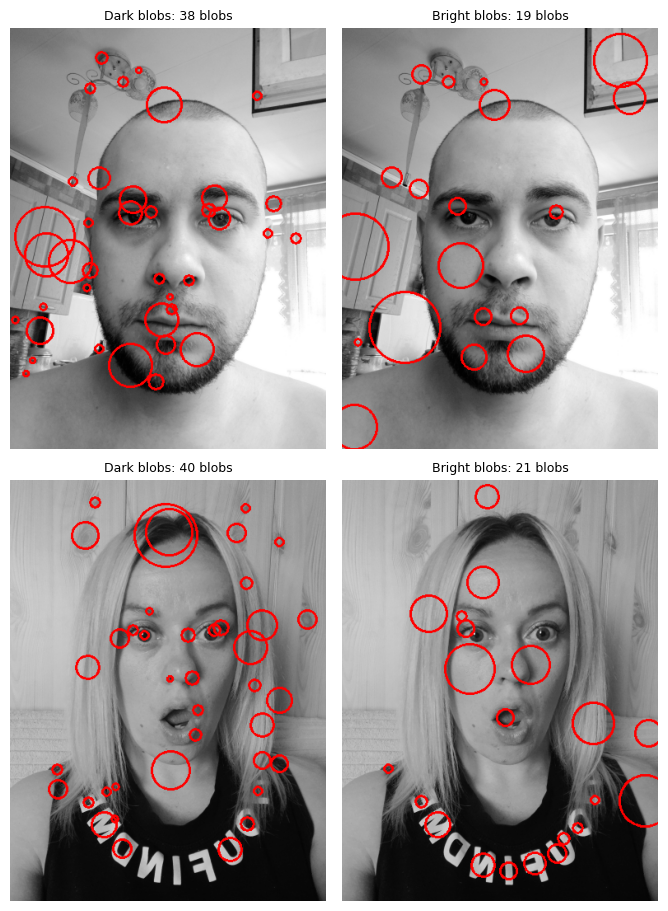

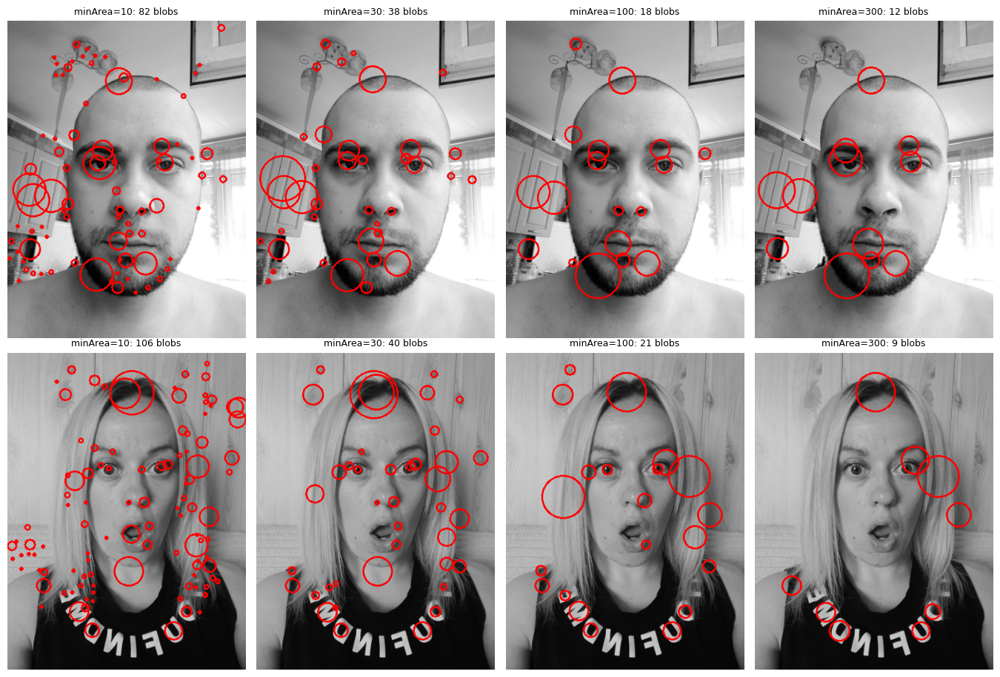

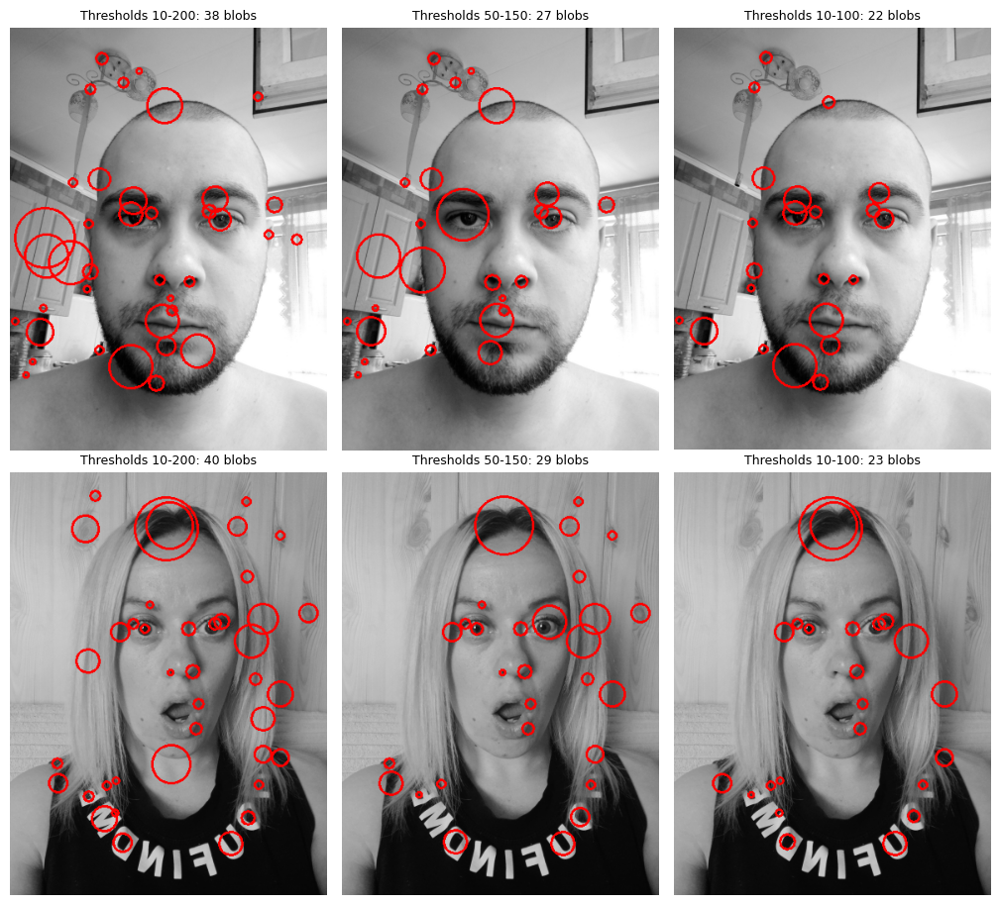

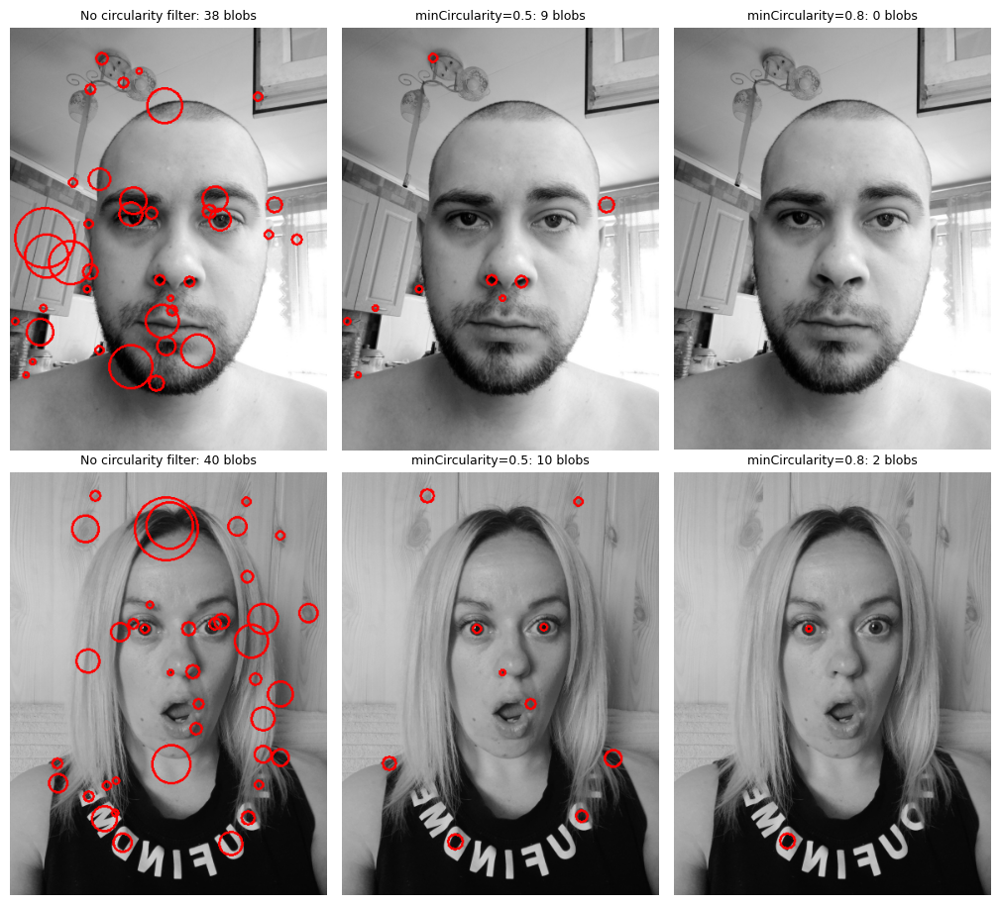

In [30]:
def vis_varianter(varianter, finn_og_tegn, filnavn, enhet):
    """varianter: liste med (tekst, innstillinger). finn_og_tegn(bilde, innstillinger) gir (fargebilde, antall)."""
    fig, akser = plt.subplots(len(EKSPERIMENT_BILDER), len(varianter),
                              figsize=(3.4 * len(varianter), 4.6 * len(EKSPERIMENT_BILDER)), squeeze=False)
    for rad, (person, uttrykk) in enumerate(EKSPERIMENT_BILDER):
        b = les_graa(person, uttrykk)
        for kol, (tekst, innstillinger) in enumerate(varianter):
            tegnet, antall = finn_og_tegn(b, innstillinger)
            akser[rad, kol].imshow(tegnet, cmap="gray")
            akser[rad, kol].set_title(f"{tekst}: {antall} {enhet}", fontsize=9)
            akser[rad, kol].axis("off")
            loggtekst.append(f"{filnavn} | person {person} {uttrykk} | {tekst} | {antall} {enhet}")
    plt.tight_layout()
    lagre_figur(filnavn)

def blob_variant(bilde, innstillinger):
    blobs = finn_blobs(bilde, **innstillinger)
    return tegn_blobs(bilde, blobs), len(blobs)

vis_varianter([("Dark blobs", {"farge": 0}), ("Bright blobs", {"farge": 255})],
              blob_variant, "fig_blob_2_farge", "blobs")

vis_varianter([(f"minArea={a}", {"min_areal": a}) for a in [10, 30, 100, 300]],
              blob_variant, "fig_blob_3_min_areal", "blobs")

vis_varianter([("Thresholds 10-200", {"min_terskel": 10, "maks_terskel": 200}),
               ("Thresholds 50-150", {"min_terskel": 50, "maks_terskel": 150}),
               ("Thresholds 10-100", {"min_terskel": 10, "maks_terskel": 100})],
              blob_variant, "fig_blob_4_terskler", "blobs")

vis_varianter([("No circularity filter", {}),
               ("minCircularity=0.5", {"min_sirkularitet": 0.5}),
               ("minCircularity=0.8", {"min_sirkularitet": 0.8})],
              blob_variant, "fig_blob_5_sirkularitet", "blobs")

---
# Del 6: Contour detection

Samme åtte bilder som i del 5. Vi følger oppskriften fra forelesningen:

1. Glatt bildet med gaussisk filter for å dempe støy.
2. Gjør bildet binært, enten med en terskel eller med Canny kantdeteksjon.
3. `cv2.findContours` finner omrisset av hvert hvitt, sammenhengende område.
4. Areal og omkrets beregnes med `cv2.contourArea` og `cv2.arcLength`.

**Valg av polaritet.** `findContours` leter etter hvite områder. Vi bruker `THRESH_BINARY_INV`, slik at mørke områder
(hår, øyne, skjegg, munn) blir hvite i det binære bildet. Da leter vi etter samme type struktur som blob-detektoren
med `farge=0`, og de to metodene kan sammenlignes direkte.

Svært små konturer (areal under 50 piksler) regnes som støy og fjernes. Antallet som fjernes telles.

In [31]:
def finn_konturer(bilde, terskel=120, filterstr=5, modus=cv2.RETR_EXTERNAL,
                  inverter=True, canny=None, min_areal=50, min_omkrets=0):
    glattet = cv2.GaussianBlur(bilde, (filterstr, filterstr), 0)
    if canny is not None:
        binaer = cv2.Canny(glattet, canny[0], canny[1])
    else:
        type_ = cv2.THRESH_BINARY_INV if inverter else cv2.THRESH_BINARY
        if terskel == "otsu":
            _, binaer = cv2.threshold(glattet, 0, 255, type_ + cv2.THRESH_OTSU)
        else:
            _, binaer = cv2.threshold(glattet, terskel, 255, type_)
    alle, _ = cv2.findContours(binaer, modus, cv2.CHAIN_APPROX_SIMPLE)
    beholdt = [k for k in alle
               if cv2.contourArea(k) >= min_areal and cv2.arcLength(k, True) >= min_omkrets]
    return beholdt, len(alle) - len(beholdt), binaer

def tegn_konturer(bilde, konturer):
    farget = cv2.cvtColor(bilde, cv2.COLOR_GRAY2RGB)
    rng = np.random.default_rng(FRO)
    for kontur in konturer:
        farge = tuple(int(v) for v in rng.integers(60, 256, 3))
        cv2.drawContours(farget, [kontur], -1, farge, 2)
    return farget

def kontur_statistikk(konturer):
    areal = [cv2.contourArea(k) for k in konturer]
    omkrets = [cv2.arcLength(k, True) for k in konturer]
    return pd.DataFrame({"areal": areal, "omkrets": omkrets})

## 6.1 Konturer på de åtte bildene, med statistikk

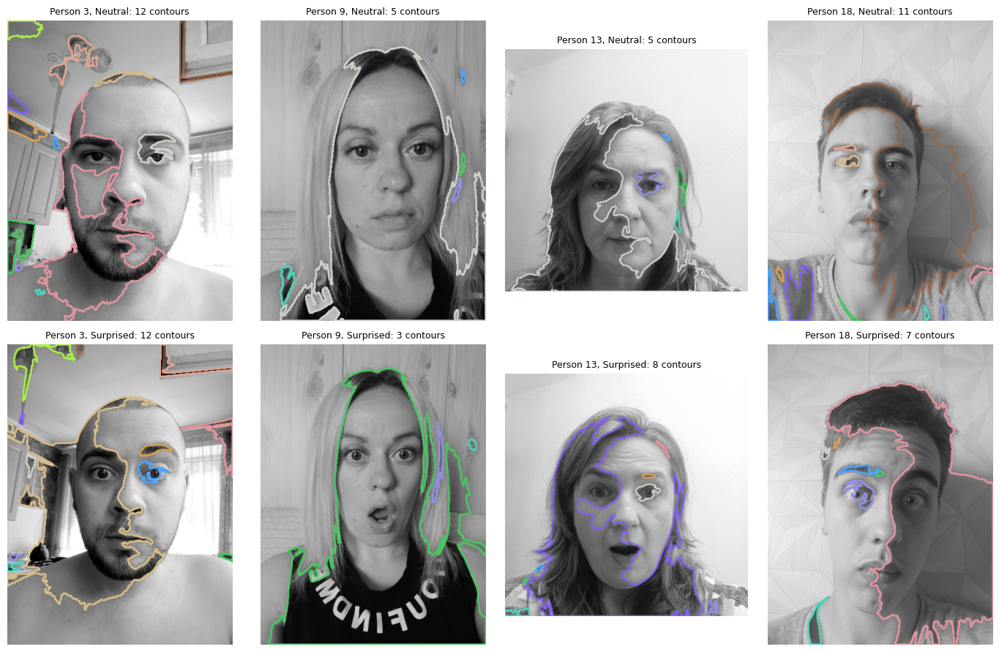

,person,uttrykk,antall,fjernet_smaa,areal_snitt,areal_storst,omkrets_snitt,omkrets_storst
0,3,Neutral,12,30,3345.0,28966.0,394.0,2143.0
1,3,Surprised,12,15,4238.0,43585.0,378.0,2366.0
2,9,Neutral,5,12,19583.0,96622.0,620.0,2658.0
3,9,Surprised,3,10,32857.0,97752.0,1120.0,2989.0
4,13,Neutral,5,13,12767.0,61300.0,633.0,2549.0
5,13,Surprised,8,37,9274.0,71830.0,504.0,3238.0
6,18,Neutral,11,14,4609.0,45246.0,284.0,1793.0
7,18,Surprised,7,8,9749.0,65582.0,404.0,1998.0


In [32]:
linjer = []
kontur_antall = {}
fig, akser = plt.subplots(2, 4, figsize=(14, 9))
for kol, (person, uttrykk) in enumerate(BLOB_BILDER):
    b = les_graa(person, uttrykk)
    konturer, fjernet, _ = finn_konturer(b)
    s = kontur_statistikk(konturer)
    kontur_antall[(person, uttrykk)] = len(konturer)
    ax = akser[kol % 2, kol // 2]
    ax.imshow(tegn_konturer(b, konturer))
    ax.set_title(f"Person {person}, {uttrykk}: {len(konturer)} contours", fontsize=9)
    ax.axis("off")
    linjer.append({"person": person, "uttrykk": uttrykk, "antall": len(konturer), "fjernet_smaa": fjernet,
                   "areal_snitt": round(s["areal"].mean(), 0) if len(s) else 0,
                   "areal_storst": round(s["areal"].max(), 0) if len(s) else 0,
                   "omkrets_snitt": round(s["omkrets"].mean(), 0) if len(s) else 0,
                   "omkrets_storst": round(s["omkrets"].max(), 0) if len(s) else 0})
plt.tight_layout()
lagre_figur("fig_kontur_1_atte_bilder")
lagre_tabell(pd.DataFrame(linjer), "tab_kontur_per_bilde")

Det binære bildet forklarer hvorfor konturene blir som de blir. Her vises glattet bilde, binært bilde og konturer for ett bilde.

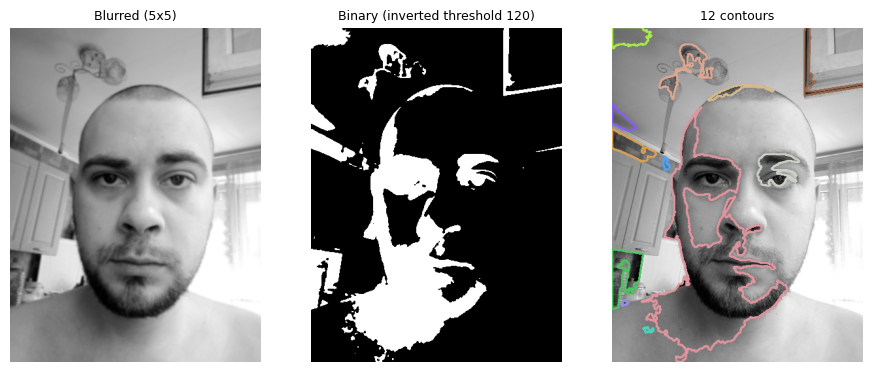

In [33]:
b = les_graa(3, "Neutral")
konturer, _, binaer = finn_konturer(b)
fig, akser = plt.subplots(1, 3, figsize=(11, 5))
vis(akser[0], cv2.GaussianBlur(b, (5, 5), 0), "Blurred (5x5)")
vis(akser[1], binaer, "Binary (inverted threshold 120)")
akser[2].imshow(tegn_konturer(b, konturer))
akser[2].set_title(f"{len(konturer)} contours", fontsize=9)
akser[2].axis("off")
lagre_figur("fig_kontur_2_steg")

## 6.2 Effekt av parametere

- **Terskel:** bestemmer hvilke piksler som regnes som mørke. Otsu velger terskelen automatisk ut fra histogrammet.
- **Filterstørrelse:** hvor mye bildet glattes før terskling.
- **Hentemodus:** `RETR_EXTERNAL` gir bare ytterste kontur, `RETR_LIST` gir også konturer inni andre.
- **Polaritet:** om mørke eller lyse områder er objektene.
- **Canny:** bruker kanter i stedet for flater som utgangspunkt. Kantene er tynne linjer med nesten null areal,
  så her filtrerer vi på omkrets (minst 40 piksler) i stedet for areal.

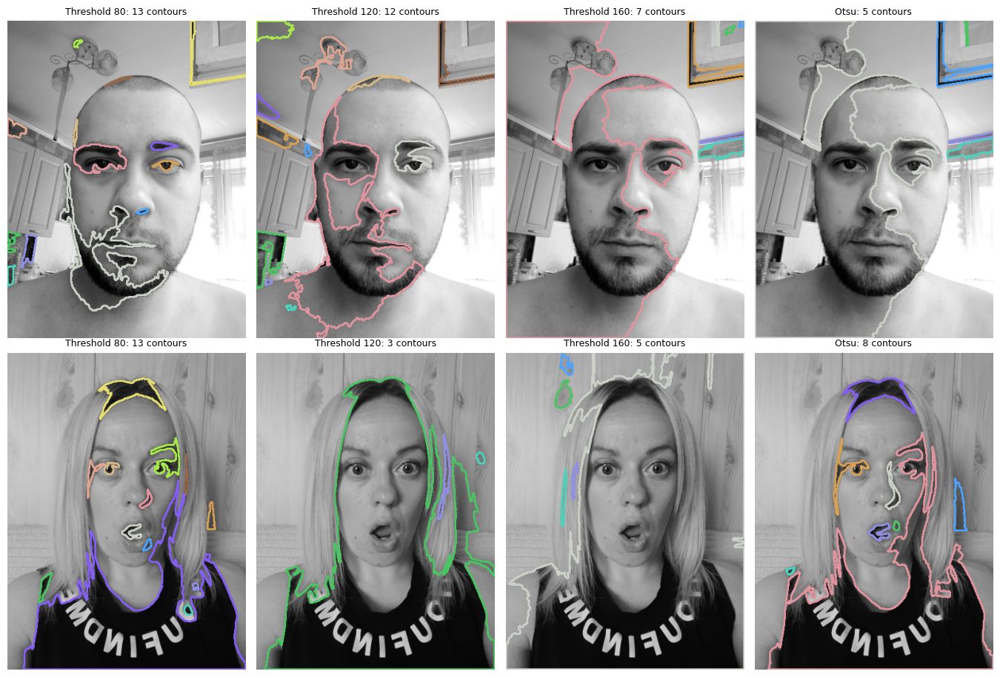

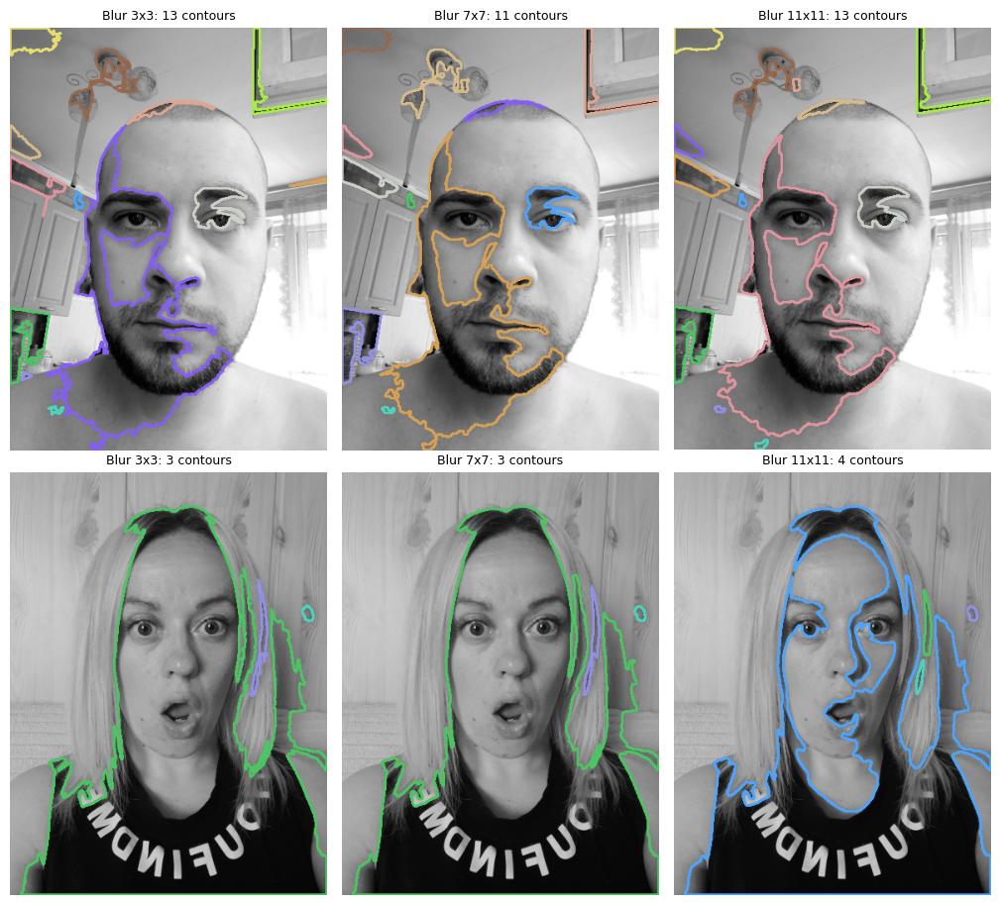

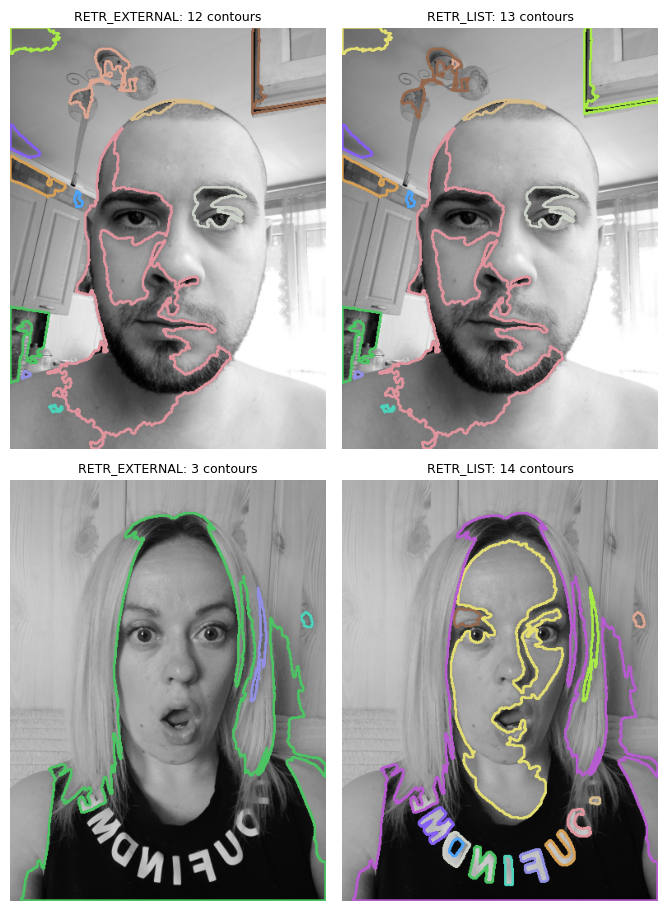

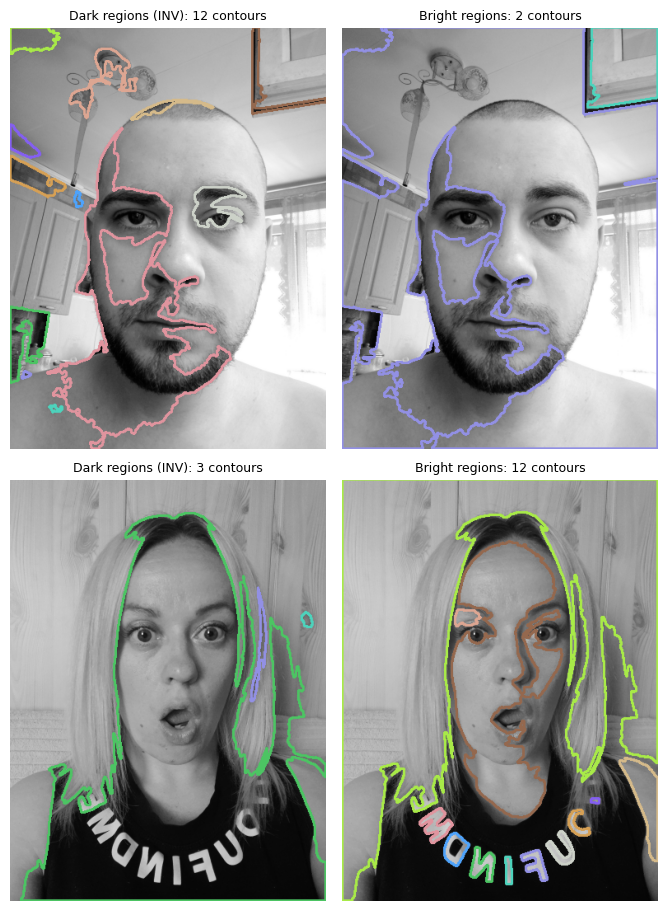

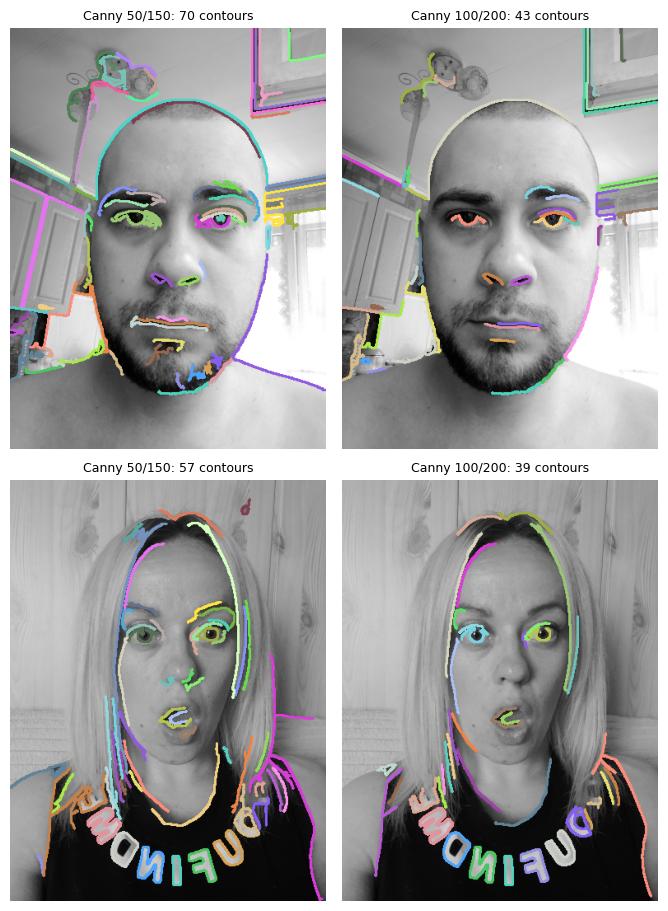

Kontur: Otsu-terskel for person 3 Neutral = 158
Kontur: Otsu-terskel for person 9 Surprised = 95


In [34]:
def kontur_variant(bilde, innstillinger):
    konturer, _, _ = finn_konturer(bilde, **innstillinger)
    return tegn_konturer(bilde, konturer), len(konturer)

vis_varianter([(f"Threshold {t}", {"terskel": t}) for t in [80, 120, 160]] + [("Otsu", {"terskel": "otsu"})],
              kontur_variant, "fig_kontur_3_terskel", "contours")

vis_varianter([(f"Blur {f}x{f}", {"filterstr": f}) for f in [3, 7, 11]],
              kontur_variant, "fig_kontur_4_filter", "contours")

vis_varianter([("RETR_EXTERNAL", {"modus": cv2.RETR_EXTERNAL}), ("RETR_LIST", {"modus": cv2.RETR_LIST})],
              kontur_variant, "fig_kontur_5_modus", "contours")

vis_varianter([("Dark regions (INV)", {"inverter": True}), ("Bright regions", {"inverter": False})],
              kontur_variant, "fig_kontur_6_polaritet", "contours")

vis_varianter([("Canny 50/150", {"canny": (50, 150), "min_areal": 0, "min_omkrets": 40}),
               ("Canny 100/200", {"canny": (100, 200), "min_areal": 0, "min_omkrets": 40})],
              kontur_variant, "fig_kontur_7_canny", "contours")

for b_person, b_uttrykk in EKSPERIMENT_BILDER:
    brukt, _ = cv2.threshold(cv2.GaussianBlur(les_graa(b_person, b_uttrykk), (5, 5), 0), 0, 255,
                             cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    logg(f"Kontur: Otsu-terskel for person {b_person} {b_uttrykk} = {brukt:.0f}")

## 6.3 Blob mot kontur

Samme bilder, samme type struktur (mørke områder), to metoder. Tabellen viser antall treff per bilde,
og figuren viser resultatene side om side.

,person,uttrykk,antall_blobs,antall_konturer
0,3,Neutral,38,12
1,3,Surprised,36,12
2,9,Neutral,30,5
3,9,Surprised,40,3
4,13,Neutral,32,5
5,13,Surprised,51,8
6,18,Neutral,19,11
7,18,Surprised,16,7


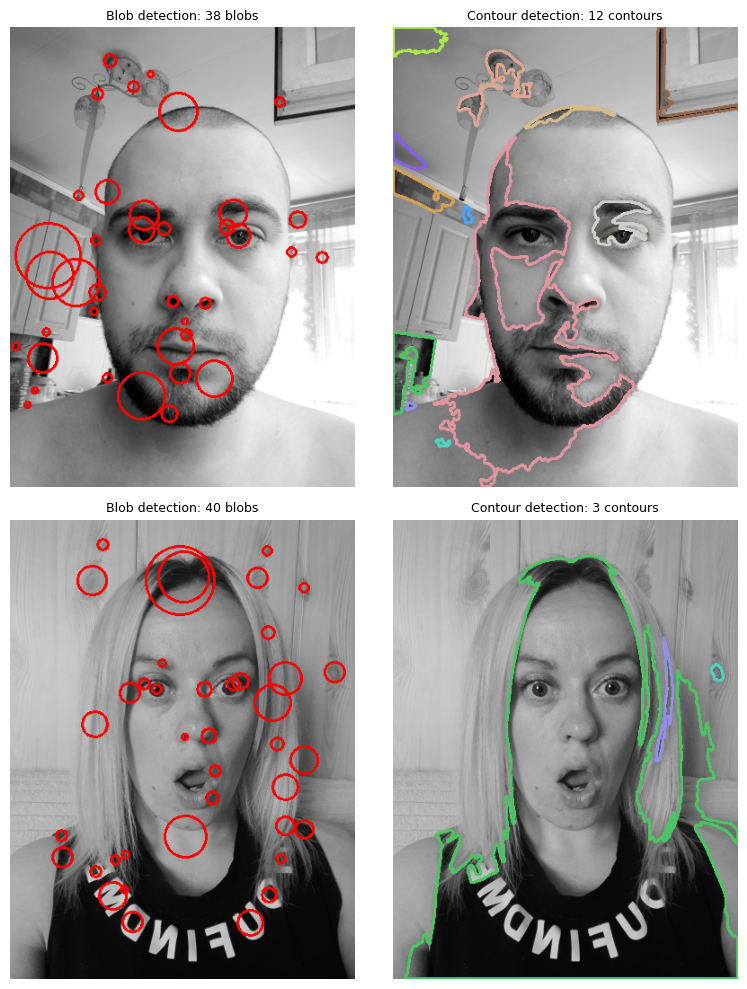

In [35]:
sammenligning = pd.DataFrame([{"person": p, "uttrykk": u,
                               "antall_blobs": blob_antall[(p, u)],
                               "antall_konturer": kontur_antall[(p, u)]} for p, u in BLOB_BILDER])
lagre_tabell(sammenligning, "tab_blob_mot_kontur")

fig, akser = plt.subplots(2, 2, figsize=(8, 10))
for rad, (person, uttrykk) in enumerate(EKSPERIMENT_BILDER):
    b = les_graa(person, uttrykk)
    blobs = finn_blobs(b)
    konturer, _, _ = finn_konturer(b)
    akser[rad, 0].imshow(tegn_blobs(b, blobs))
    akser[rad, 0].set_title(f"Blob detection: {len(blobs)} blobs", fontsize=9)
    akser[rad, 1].imshow(tegn_konturer(b, konturer))
    akser[rad, 1].set_title(f"Contour detection: {len(konturer)} contours", fontsize=9)
    akser[rad, 0].axis("off")
    akser[rad, 1].axis("off")
plt.tight_layout()
lagre_figur("fig_kontur_8_blob_mot_kontur")

---
# Samle resultatene

Denne cellen lager to filer:

- `resultater.txt` med alle tall og tabeller.
- `alle_figurer.pdf` med alle figurene, én per side.

In [36]:
from PIL import Image

Path("resultater.txt").write_text("\n".join(loggtekst), encoding="utf-8")

sider = []
for fil in figurliste:
    side = Image.open(fil).convert("RGB")
    side.thumbnail((1600, 1600))
    sider.append(side)
sider[0].save("alle_figurer.pdf", save_all=True, append_images=sider[1:])
print(f"Lagret resultater.txt og alle_figurer.pdf ({len(sider)} figurer)")

Lagret resultater.txt og alle_figurer.pdf (36 figurer)
